In [51]:
import pandas as pd
import numpy as np

In [52]:
df = pd.read_excel('ckd_data.xlsx')

In [53]:
print(df.head())

   Age   Gender  Socioeconomic Status  Weight (kg)  Height (cm)          Bmi  \
0   25        0                     0           58            152  25.103878   
1   24        1                     1           48            165  17.630854   
2   29        0                     1           59            158  23.634033   
3   35        0                     1           52            159  20.568807   
4   46        0                     1           72            158  28.841532   

   Bmi Category  Edema (swelling)  Urination frequency  Sleep duration  ...  \
0             3                 0                    2               2  ...   
1             0                 0                    0               2  ...   
2             2                 0                    0               0  ...   
3             1                 2                    3               2  ...   
4             3                 2                    2               2  ...   

   Daily stress level  Herbal/traditional su

In [54]:
df.columns = df.columns.str.strip()

In [55]:
print(df.shape)

(1002, 27)


In [56]:
print(df["Age"].min())
print(df["Age"].max())

20
60


Check Columns

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                1002 non-null   int64  
 1   Gender                             1002 non-null   int64  
 2   Socioeconomic Status               1002 non-null   int64  
 3   Weight (kg)                        1002 non-null   int64  
 4   Height (cm)                        1002 non-null   int64  
 5   Bmi                                1002 non-null   float64
 6   Bmi Category                       1002 non-null   int64  
 7   Edema (swelling)                   1002 non-null   int64  
 8   Urination frequency                1002 non-null   int64  
 9   Sleep duration                     1002 non-null   int64  
 10  Water intake                       1002 non-null   int64  
 11  Salt (sodium) intake               1002 non-null   int64

Remove unnecessary columns

In [58]:
df = df.drop(columns=["Weight (kg)", "Height (cm)", "Bmi Category"])

In [59]:
group1_target_features = [
    'Personal hypertension', 'Personal diabetes',
    'Edema (swelling)', 'Urination frequency',
    'History of kidney stones/UTI', 'Painkiller (NSAID) use frequency'
]

In [60]:
df['New_Total_Risk'] = df[group1_target_features].sum(axis=1)
print("Score range:", df['New_Total_Risk'].min(), "-", df['New_Total_Risk'].max())


Score range: 0 - 15


In [61]:
df['New_Total_Risk'] = df[group1_target_features].sum(axis=1)

print(df['New_Total_Risk'].describe())
print(df['New_Total_Risk'].value_counts().sort_index())

count    1002.000000
mean        5.727545
std         4.075293
min         0.000000
25%         2.000000
50%         5.000000
75%         9.000000
max        15.000000
Name: New_Total_Risk, dtype: float64
New_Total_Risk
0      38
1     153
2      95
3      93
4      97
5      86
6      48
7      43
8      53
9      52
10     63
11     70
12     56
13     33
14     13
15      9
Name: count, dtype: int64


In [62]:
!pip install diptest

In [63]:
import diptest
dip_stat, p_value = diptest.diptest(df['New_Total_Risk'].values)
print(f"Dip statistic: {dip_stat:.4f}, p-value: {p_value:.4f}")

Dip statistic: 0.0484, p-value: 0.0000


In [64]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=2, random_state=42, n_init=10)
raw_labels = km.fit_predict(df['New_Total_Risk'].values.reshape(-1, 1))

centroid_order = np.argsort(km.cluster_centers_.flatten())
remap = {old: new for new, old in enumerate(centroid_order)}
df['CKD_Risk_Binary'] = pd.Series(raw_labels).map(remap).values

label_names = {0: 'Low Risk', 1: 'High Risk'}
df['CKD_Risk_Binary_Label'] = df['CKD_Risk_Binary'].map(label_names)

print(df['CKD_Risk_Binary_Label'].value_counts())
print((df['CKD_Risk_Binary_Label'].value_counts(normalize=True) * 100).round(1))

CKD_Risk_Binary_Label
Low Risk     610
High Risk    392
Name: count, dtype: int64
CKD_Risk_Binary_Label
Low Risk     60.9
High Risk    39.1
Name: proportion, dtype: float64


In [65]:
import pandas as pd
import numpy as np
from scipy import stats


value_labels = {
    'Gender': {0: 'Female', 1: 'Male'},
    'Socioeconomic Status': {0: 'Low', 1: 'Middle', 2: 'High'},
    'Edema (swelling)': {0: 'No', 1: 'Sometimes', 2: 'Yes', 3: 'Unmapped (check S2)'},
    'Urination frequency': {0: 'Normal', 1: 'More than usual', 2: 'Less than usual', 3: 'Increased at night'},
    'Sleep duration': {0: '7–8h', 1: 'Unmapped (check S2)', 2: '5–6h / >8h', 3: '<5h'},
    'Water intake': {0: '≥8 glasses', 1: '5–7 glasses', 2: '2–4 glasses', 3: '<2 glasses'},
    'Salt (sodium) intake': {0: 'Low', 1: 'Medium', 2: 'High'},
    'Sweets/sugary drinks intake': {0: 'Rarely', 1: '1–2x/week', 2: 'Almost daily', 3: 'Multiple times daily'},
    'Smoking Status': {0: 'Never', 1: 'Former', 2: 'Current'},
    'Alcohol Consumption': {0: 'Never', 1: 'Occasionally', 2: 'Regularly'},
    'Fast food/processed food intake': {0: 'Rarely', 1: '1–2x/week', 2: '3–5x/week', 3: 'Daily'},
    'Tea/Coffee (caffeine) intake': {0: 'None', 1: '1 cup', 2: '2–3 cups', 3: '>4 cups'},
    'Daily stress level': {0: 'None', 1: 'Mild', 2: 'Moderate', 3: 'High', 4: 'Very High'},
    'Herbal/traditional supplement use': {0: 'No', 1: 'Sometimes', 2: 'Regularly'},
    'Sedentary hours/day': {0: '<2h', 1: '2–4h', 2: '5–7h', 3: '>8h'},
    'Family history of hypertension': {0: 'No', 1: 'Not Sure', 2: 'Yes'},
    'Family history of diabetes': {0: 'No', 1: 'Not Sure', 2: 'Yes'},
    'Personal hypertension': {0: 'No', 1: 'Not Sure', 2: 'Yes'},
    'Personal diabetes': {0: 'No', 1: 'Not Sure', 2: 'Yes'},
    'Painkiller (NSAID) use frequency': {0: 'Rarely', 1: '1–2x/month', 2: '1–2x/week', 3: 'Almost daily'},
    'Environmental pollution exposure': {0: 'No', 1: 'Sometimes', 2: 'Regularly', 3: 'Unmapped (check S2)'},
    'History of kidney stones/UTI': {0: 'Neither', 1: 'History of UTI', 2: 'History of kidney stones', 3: 'Both'},
}

continuous_vars = ['Age', 'Bmi']
categorical_vars = list(value_labels.keys())
group_col = 'CKD_Risk_Binary_Label'

low_df  = df[df[group_col] == 'Low Risk']
high_df = df[df[group_col] == 'High Risk']



rows = []

# ---- Continuous variables ----
for var in continuous_vars:
    all_s  = f"{df[var].mean():.1f} ± {df[var].std():.1f}"
    low_s  = f"{low_df[var].mean():.1f} ± {low_df[var].std():.1f}"
    high_s = f"{high_df[var].mean():.1f} ± {high_df[var].std():.1f}"
    t, p = stats.ttest_ind(low_df[var], high_df[var])
    rows.append({
        'Characteristic': f'{var}, mean ± SD',
        'All (N={})'.format(len(df)): all_s,
        f'Low Risk (n={len(low_df)})': low_s,
        f'High Risk (n={len(high_df)})': high_s,
        'p-value': "<0.001" if p < 0.001 else f"{p:.3f}",
        'Missing, n (%)': f"{df[var].isna().sum()} ({100*df[var].isna().mean():.1f}%)"
    })

# ---- Categorical variables ----
for var in categorical_vars:
    contingency = pd.crosstab(df[var], df[group_col])
    try:
        chi2, p, dof, exp = stats.chi2_contingency(contingency)
        p_str = "<0.001" if p < 0.001 else f"{p:.3f}"
    except ValueError:
        p_str = "NA"

    rows.append({
        'Characteristic': f'{var}',
        'All (N={})'.format(len(df)): '', f'Low Risk (n={len(low_df)})': '',
        f'High Risk (n={len(high_df)})': '', 'p-value': p_str,
        'Missing, n (%)': f"{df[var].isna().sum()} ({100*df[var].isna().mean():.1f}%)"
    })

    for level in sorted(df[var].dropna().unique()):
        label = value_labels[var].get(level, str(level))
        n_all  = (df[var] == level).sum()
        n_low  = (low_df[var] == level).sum()
        n_high = (high_df[var] == level).sum()
        rows.append({
            'Characteristic': f'   {label}',
            'All (N={})'.format(len(df)): f"{n_all} ({100*n_all/len(df):.1f}%)",
            f'Low Risk (n={len(low_df)})': f"{n_low} ({100*n_low/len(low_df):.1f}%)",
            f'High Risk (n={len(high_df)})': f"{n_high} ({100*n_high/len(high_df):.1f}%)",
            'p-value': '',
            'Missing, n (%)': ''
        })

char_table = pd.DataFrame(rows)
display(char_table)

char_table.to_excel('participant_characteristics_table.xlsx', index=False)
print("\nSaved: participant_characteristics_table.xlsx")

,Characteristic,All (N=1002),Low Risk (n=610),High Risk (n=392),p-value,"Missing, n (%)"
0,"Age, mean ± SD",32.2 ± 8.8,27.9 ± 5.3,38.9 ± 9.0,<0.001,0 (0.0%)
1,"Bmi, mean ± SD",23.8 ± 3.5,23.4 ± 3.3,24.3 ± 3.6,<0.001,0 (0.0%)
2,Gender,,,,0.185,0 (0.0%)
3,Female,382 (38.1%),243 (39.8%),139 (35.5%),,
4,Male,620 (61.9%),367 (60.2%),253 (64.5%),,
...,...,...,...,...,...,...
94,History of kidney stones/UTI,,,,<0.001,0 (0.0%)
95,Neither,661 (66.0%),551 (90.3%),110 (28.1%),,
96,History of UTI,154 (15.4%),35 (5.7%),119 (30.4%),,
97,History of kidney stones,144 (14.4%),22 (3.6%),122 (31.1%),,



Saved: participant_characteristics_table.xlsx


In [66]:
from sklearn.metrics import silhouette_score
import scipy.stats as stats

sil = silhouette_score(df['New_Total_Risk'].values.reshape(-1, 1), df['CKD_Risk_Binary'])
print(f"Silhouette score: {sil:.4f}")

summary = df.groupby('CKD_Risk_Binary_Label').agg(
    score_min=('New_Total_Risk', 'min'),
    score_max=('New_Total_Risk', 'max'),
    score_mean=('New_Total_Risk', 'mean'),
    count=('New_Total_Risk', 'count')
).reindex(['Low Risk', 'High Risk'])
print(summary)

face_validity = df.groupby('CKD_Risk_Binary_Label')[['Age', 'Bmi']].mean()
print(face_validity)

low_age = df[df['CKD_Risk_Binary_Label']=='Low Risk']['Age']
high_age = df[df['CKD_Risk_Binary_Label']=='High Risk']['Age']
t_stat, p_val = stats.ttest_ind(low_age, high_age)
print(f"t-test p-value (Age): {p_val:.4f}")

low_bmi = df[df['CKD_Risk_Binary_Label']=='Low Risk']['Bmi']
high_bmi = df[df['CKD_Risk_Binary_Label']=='High Risk']['Bmi']
t_stat_bmi, p_val_bmi = stats.ttest_ind(low_bmi, high_bmi)
print(f"t-test p-value (BMI): {p_val_bmi:.4f}")

Silhouette score: 0.6817
                       score_min  score_max  score_mean  count
CKD_Risk_Binary_Label                                         
Low Risk                       0          6    2.832787    610
High Risk                      7         15   10.232143    392
                             Age        Bmi
CKD_Risk_Binary_Label                      
High Risk              38.867347  24.315420
Low Risk               27.904918  23.431277
t-test p-value (Age): 0.0000
t-test p-value (BMI): 0.0001


In [67]:
predictor_cols = [c for c in df.columns
                   if c not in group1_target_features + [
                       'CKD_Risk', 'CKD_Risk_Label', 'New_Total_Risk',
                       'CKD_Risk_Binary', 'CKD_Risk_Binary_Label'
                   ]]

X = df[predictor_cols]
y = df['CKD_Risk_Binary']

print(f"Predictor count: {len(predictor_cols)}")
print(predictor_cols)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=40, stratify=y
)
print("Train:", y_train.value_counts(normalize=True).round(3))
print("Test:", y_test.value_counts(normalize=True).round(3))

Predictor count: 18
['Age', 'Gender', 'Socioeconomic Status', 'Bmi', 'Sleep duration', 'Water intake', 'Salt (sodium) intake', 'Sweets/sugary drinks intake', 'Smoking Status', 'Alcohol Consumption', 'Fast food/processed food intake', 'Tea/Coffee (caffeine) intake', 'Daily stress level', 'Herbal/traditional supplement use', 'Sedentary hours/day', 'Family history of hypertension', 'Family history of diabetes', 'Environmental pollution exposure']
Train: CKD_Risk_Binary
0    0.609
1    0.391
Name: proportion, dtype: float64
Test: CKD_Risk_Binary
0    0.607
1    0.393
Name: proportion, dtype: float64


In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline as SklearnPipeline

from sklearn.metrics import make_scorer, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

# scale_pos_weight for XGBoost (binary imbalance handling)
class_counts = y_train.value_counts()
scale_pos_weight = class_counts[0] / class_counts[1]
print(f"scale_pos_weight: {scale_pos_weight:.3f}")

# Base models — binary objective now, with class-imbalance handling
lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42
)
svm_model = SVC(random_state=42, probability=True, class_weight='balanced')
lgbm_model = LGBMClassifier(random_state=42, verbose=-1, is_unbalance=True)

print("Base models instantiated successfully.")

scale_pos_weight: 1.559
Base models instantiated successfully.


In [69]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

# --- Sample weights (kept for consistency, though XGB will also get scale_pos_weight) ---
sample_weights = compute_sample_weight('balanced', y_train)

class_counts = y_train.value_counts()
scale_pos_weight = class_counts[0] / class_counts[1]

# --- Pipelines with StandardScaler for scale-sensitive models ---
lr_pipeline_a  = SklearnPipeline([('scaler', StandardScaler()),
                                   ('model', LogisticRegression(random_state=42, max_iter=1000))])
svm_pipeline_a = SklearnPipeline([('scaler', StandardScaler()),
                                   ('model', SVC(random_state=42, probability=True))])

# --- Hyperparameter grids ---
param_grid_lr = {
    'model__class_weight': ['balanced'],
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__solver': ['liblinear', 'saga'],
    'model__penalty': ['l1', 'l2']
}

param_grid_rf = {
    'class_weight': ['balanced', 'balanced_subsample'],
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5]
}

# XGBoost — binary objective now; scale_pos_weight set as fixed value (computed above)
param_grid_xgb = {
    'objective': ['binary:logistic'],
    'scale_pos_weight': [scale_pos_weight],
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.005, 0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 7],
    'subsample': [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1.0],
    'reg_lambda': [0.5, 1.0, 5.0, 10.0],
    'min_child_weight': [1, 3, 5]
}

param_grid_svm = {
    'model__class_weight': ['balanced'],
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__kernel': ['linear', 'rbf', 'poly'],
    'model__gamma': ['scale', 'auto']
}

param_grid_lgbm = {
    'class_weight': ['balanced'],
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.005, 0.01, 0.05, 0.1, 0.2],
    'max_depth': [-1, 5, 10, 20],
    'num_leaves': [15, 31, 63, 127],
    'min_child_samples': [5, 10, 20, 30],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1.0],
    'reg_lambda': [0, 0.01, 0.1, 1.0]
}

# Setup CV and scoring — binary target now, so plain 'roc_auc' works directly
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = {'f1': 'f1', 'roc_auc': 'roc_auc'}

models_and_grids = {
    'Logistic Regression': (lr_pipeline_a,  param_grid_lr),
    'Random Forest':       (rf_model,        param_grid_rf),
    'XGBoost':             (xgb_model,       param_grid_xgb),
    'SVM':                 (svm_pipeline_a,  param_grid_svm),
    'LightGBM':            (LGBMClassifier(random_state=42, verbose=-1), param_grid_lgbm)
}

# fit_params: none required now since class_weight/scale_pos_weight handle imbalance via grid
fit_params_by_model = {
    'Logistic Regression': {},
    'Random Forest':       {},
    'XGBoost':             {},
    'SVM':                 {},
    'LightGBM':            {}
}

strategy_a_results = {}

for model_name, (model, param_grid) in models_and_grids.items():
    print(f"Evaluating {model_name}...")
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=40,
        scoring=scoring,
        refit='f1',
        cv=cv,
        random_state=42,
        n_jobs=-1,
        error_score='raise'
    )
    search.fit(X_train, y_train, **fit_params_by_model[model_name])
    best_index = search.best_index_
    strategy_a_results[model_name] = {
        'Best_Params':    search.best_params_,
        'Best_Estimator': search.best_estimator_,
        'Mean_F1':        search.cv_results_['mean_test_f1'][best_index],
        'Std_F1':         search.cv_results_['std_test_f1'][best_index],
        'Mean_ROC_AUC':   search.cv_results_['mean_test_roc_auc'][best_index],
        'Std_ROC_AUC':    search.cv_results_['std_test_roc_auc'][best_index]
    }
    print(f"  Best F1: {strategy_a_results[model_name]['Mean_F1']:.4f}  "
          f"ROC AUC: {strategy_a_results[model_name]['Mean_ROC_AUC']:.4f}")

print("\nStrategy A Evaluation Complete.")

Evaluating Logistic Regression...


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 24 is smaller than n_iter=40. Running 24 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  Best F1: 0.7384  ROC AUC: 0.8746
Evaluating Random Forest...
  Best F1: 0.7445  ROC AUC: 0.8735
Evaluating XGBoost...
  Best F1: 0.7535  ROC AUC: 0.8705
Evaluating SVM...


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 30 is smaller than n_iter=40. Running 30 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  Best F1: 0.7307  ROC AUC: 0.8692
Evaluating LightGBM...
  Best F1: 0.7522  ROC AUC: 0.8736

Strategy A Evaluation Complete.


In [70]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

# --- Pipelines ---
smote_pipeline_lr = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])
smote_pipeline_rf = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42))
])
smote_pipeline_xgb = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(random_state=42, eval_metric='logloss', objective='binary:logistic'))
])
smote_pipeline_svm = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model', SVC(random_state=42, probability=True))
])
smote_pipeline_lgbm = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LGBMClassifier(random_state=42, verbose=-1))
])

# --- Parameter grids (LR, RF, XGB, LightGBM — unchanged) ---
param_grid_smote_lr = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__solver': ['liblinear', 'saga'],
    'model__penalty': ['l1', 'l2']
}
param_grid_smote_rf = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [None, 5, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', 0.5]
}
param_grid_smote_xgb = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__learning_rate': [0.005, 0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 4, 5, 6, 7],
    'model__subsample': [0.6, 0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__reg_alpha': [0, 0.01, 0.1, 1.0],
    'model__reg_lambda': [0.5, 1.0, 5.0, 10.0],
    'model__min_child_weight': [1, 3, 5]
}
param_grid_smote_lgbm = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__learning_rate': [0.005, 0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [-1, 5, 10, 20],
    'model__num_leaves': [15, 31, 63, 127],
    'model__min_child_samples': [5, 10, 20, 30],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__reg_alpha': [0, 0.01, 0.1, 1.0],
    'model__reg_lambda': [0, 0.01, 0.1, 1.0]
}

# --- SVM: lightweight grid (poly kernel dropped, fewer C options) ---
param_grid_smote_svm_light = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['linear', 'rbf'],
    'model__gamma': ['scale']
}

# --- CV setup ---
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)      # LR, RF, XGB, LightGBM
cv_svm = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)   # SVM only, lighter

scoring = {'f1': 'f1', 'roc_auc': 'roc_auc'}

# --- Main loop: everything except SVM ---
models_and_grids = {
    'Logistic Regression': (smote_pipeline_lr,  param_grid_smote_lr),
    'Random Forest':       (smote_pipeline_rf,  param_grid_smote_rf),
    'XGBoost':             (smote_pipeline_xgb, param_grid_smote_xgb),
    'LightGBM':            (smote_pipeline_lgbm, param_grid_smote_lgbm)
}

strategy_b_results = {}

for model_name, (pipeline, param_grid) in models_and_grids.items():
    print(f"Evaluating {model_name} with SMOTE...")
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grid,
        n_iter=40,
        scoring=scoring,
        refit='f1',
        cv=cv,
        random_state=42,
        n_jobs=-1,
        error_score='raise'
    )
    search.fit(X_train, y_train)
    best_index = search.best_index_
    strategy_b_results[model_name] = {
        'Best_Params':    search.best_params_,
        'Best_Estimator': search.best_estimator_,
        'Mean_F1':        search.cv_results_['mean_test_f1'][best_index],
        'Std_F1':         search.cv_results_['std_test_f1'][best_index],
        'Mean_ROC_AUC':   search.cv_results_['mean_test_roc_auc'][best_index],
        'Std_ROC_AUC':    search.cv_results_['std_test_roc_auc'][best_index]
    }
    print(f"  Best F1: {strategy_b_results[model_name]['Mean_F1']:.4f}  "
          f"ROC AUC: {strategy_b_results[model_name]['Mean_ROC_AUC']:.4f}")

print("\nLR, RF, XGBoost, LightGBM done. Now running SVM separately (lightweight)...\n")

# --- SVM: separate, lightweight run ---
search_svm = RandomizedSearchCV(
    estimator=smote_pipeline_svm,
    param_distributions=param_grid_smote_svm_light,
    n_iter=6,
    scoring=scoring,
    refit='f1',
    cv=cv_svm,
    random_state=42,
    n_jobs=-1,
    error_score='raise',
    verbose=2
)

print("Evaluating SVM with SMOTE (lightweight config)...")
search_svm.fit(X_train, y_train)

best_index = search_svm.best_index_
strategy_b_results['SVM'] = {
    'Best_Params':    search_svm.best_params_,
    'Best_Estimator': search_svm.best_estimator_,
    'Mean_F1':        search_svm.cv_results_['mean_test_f1'][best_index],
    'Std_F1':         search_svm.cv_results_['std_test_f1'][best_index],
    'Mean_ROC_AUC':   search_svm.cv_results_['mean_test_roc_auc'][best_index],
    'Std_ROC_AUC':    search_svm.cv_results_['std_test_roc_auc'][best_index]
}
print(f"  Best F1: {strategy_b_results['SVM']['Mean_F1']:.4f}  "
      f"ROC AUC: {strategy_b_results['SVM']['Mean_ROC_AUC']:.4f}")

print("\nStrategy B Evaluation Complete (all 5 models).")

Evaluating Logistic Regression with SMOTE...


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 24 is smaller than n_iter=40. Running 24 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  Best F1: 0.7222  ROC AUC: 0.8718
Evaluating Random Forest with SMOTE...
  Best F1: 0.7352  ROC AUC: 0.8724
Evaluating XGBoost with SMOTE...
  Best F1: 0.7504  ROC AUC: 0.8735
Evaluating LightGBM with SMOTE...
  Best F1: 0.7300  ROC AUC: 0.8665

LR, RF, XGBoost, LightGBM done. Now running SVM separately (lightweight)...

Evaluating SVM with SMOTE (lightweight config)...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
  Best F1: 0.7189  ROC AUC: 0.8658

Strategy B Evaluation Complete (all 5 models).


In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine results into a single list of records
records = []

for model_name, metrics in strategy_a_results.items():
    records.append({
        'Model': model_name,
        'Strategy': 'Class Weighting',
        'Mean_F1': metrics['Mean_F1'],
        'Mean_ROC_AUC': metrics['Mean_ROC_AUC']
    })

for model_name, metrics in strategy_b_results.items():
    records.append({
        'Model': model_name,
        'Strategy': 'SMOTE',
        'Mean_F1': metrics['Mean_F1'],
        'Mean_ROC_AUC': metrics['Mean_ROC_AUC']
    })

# Create a DataFrame
results_df = pd.DataFrame(records)

# Display the DataFrame
display(results_df)


,Model,Strategy,Mean_F1,Mean_ROC_AUC
0,Logistic Regression,Class Weighting,0.738445,0.874647
1,Random Forest,Class Weighting,0.744473,0.873468
2,XGBoost,Class Weighting,0.753505,0.870457
3,SVM,Class Weighting,0.730727,0.869152
4,LightGBM,Class Weighting,0.752210,0.873620
5,Logistic Regression,SMOTE,0.722216,0.871830
6,Random Forest,SMOTE,0.735204,0.872438
7,XGBoost,SMOTE,0.750355,0.873539
8,LightGBM,SMOTE,0.730044,0.866456
9,SVM,SMOTE,0.718939,0.865808


In [72]:
from sklearn.calibration import CalibratedClassifierCV

# --- Systematically select the best model across ALL strategies and models ---
all_cv_results = {}
for model_name, metrics in strategy_a_results.items():
    all_cv_results[(model_name, 'Class Weighting')] = metrics
for model_name, metrics in strategy_b_results.items():
    all_cv_results[(model_name, 'SMOTE')] = metrics

best_key = max(all_cv_results, key=lambda k: all_cv_results[k]['Mean_F1'])
best_model_name, best_strategy = best_key
best_cv_metrics = all_cv_results[best_key]

print("=== Global Best Model ===")
print(f"Model:    {best_model_name}")
print(f"Strategy: {best_strategy}")
print(f"CV F1: {best_cv_metrics['Mean_F1']:.4f} "
      f"(+/- {best_cv_metrics['Std_F1']:.4f})")
print(f"CV ROC AUC:  {best_cv_metrics['Mean_ROC_AUC']:.4f} "
      f"(+/- {best_cv_metrics['Std_ROC_AUC']:.4f})")
print(f"Best Params: {best_cv_metrics['Best_Params']}")

# Retrieve the already-fitted best estimator (pipeline or plain model) from search
best_estimator = best_cv_metrics['Best_Estimator']

# Keep rf_best pointing to the best estimator for SHAP compatibility downstream
rf_best = best_estimator

# Calibrate with isotonic regression (5-fold internal CV)
calibrated_rf = CalibratedClassifierCV(estimator=best_estimator, cv=5, method='isotonic')
calibrated_rf.fit(X_train, y_train)

y_pred  = calibrated_rf.predict(X_test)
y_proba = calibrated_rf.predict_proba(X_test)[:, 1]

print("\nModel calibration and prediction completed.")

=== Global Best Model ===
Model:    XGBoost
Strategy: Class Weighting
CV F1: 0.7535 (+/- 0.0494)
CV ROC AUC:  0.8705 (+/- 0.0314)
Best Params: {'subsample': 0.7, 'scale_pos_weight': np.float64(1.5591054313099042), 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'objective': 'binary:logistic', 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.005, 'colsample_bytree': 0.8}

Model calibration and prediction completed.


Performance Curves Visualization

Brier Score: 0.1191


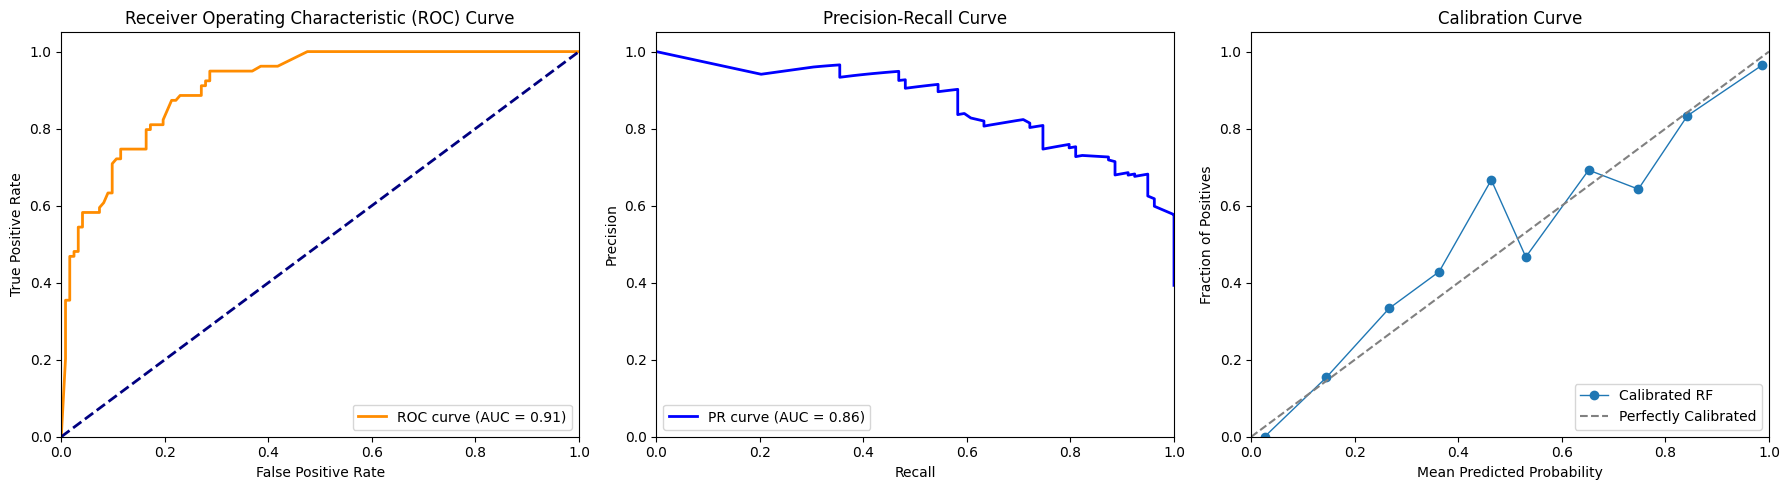

In [73]:
from sklearn.metrics import brier_score_loss, roc_curve, auc, precision_recall_curve
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Calculate Brier Score
brier_score = brier_score_loss(y_test, y_proba)
print(f"Brier Score: {brier_score:.4f}")

# Calculate ROC metrics
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Calculate PR metrics
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)

# Calculate Calibration curve metrics
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. ROC Curve
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[0].legend(loc="lower right")

# 2. Precision-Recall Curve
axes[1].plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.2f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc="lower left")

# 3. Calibration Curve
axes[2].plot(prob_pred, prob_true, marker='o', linewidth=1, label='Calibrated RF')
axes[2].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('Mean Predicted Probability')
axes[2].set_ylabel('Fraction of Positives')
axes[2].set_title('Calibration Curve')
axes[2].legend(loc="lower right")

plt.tight_layout()
fig.savefig("ALL Curve", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

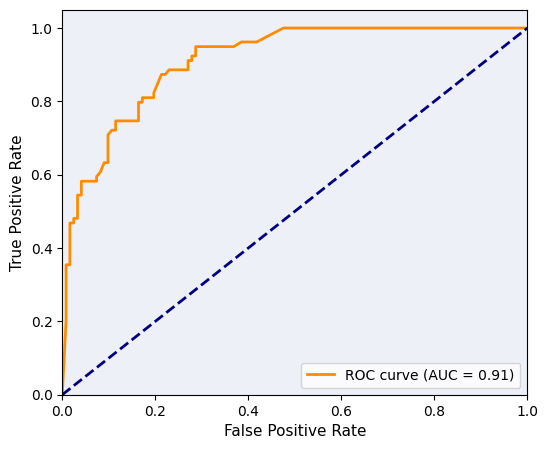

In [74]:
import matplotlib.pyplot as plt


plt.style.use("default")

fig, ax = plt.subplots(figsize=(6, 5))


ax.set_facecolor("#eef0f8")
fig.patch.set_facecolor("white")

# ROC Curve
ax.plot(
    fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})"
)
ax.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])


ax.set_xlabel("False Positive Rate", fontsize=11, color="black")
ax.set_ylabel("True Positive Rate", fontsize=11, color="black")
ax.tick_params(colors="black", labelsize=10)

ax.legend(loc="lower right")

fig.savefig("roc_curve", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

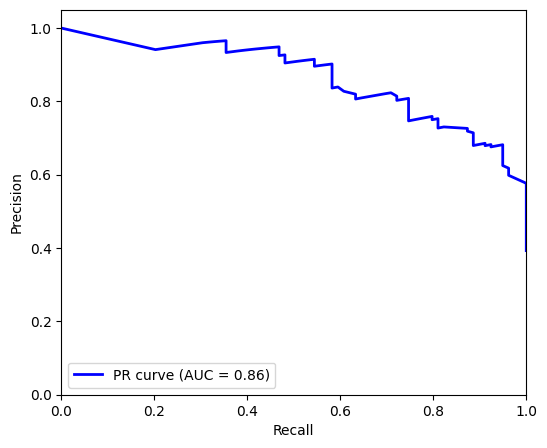

In [75]:
fig, ax = plt.subplots(figsize=(6, 5))

# Precision-Recall Curve
ax.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.2f})')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(loc="lower left")


fig.savefig("precision_recall_curve.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

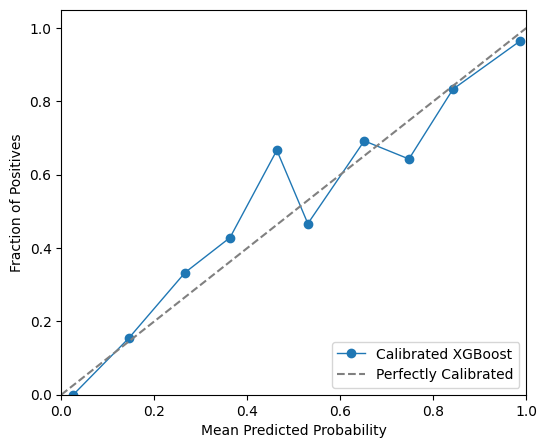

In [76]:
fig, ax = plt.subplots(figsize=(6, 5))

# Calibration Curve
ax.plot(prob_pred, prob_true, marker='o', linewidth=1, label='Calibrated XGBoost')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.legend(loc="lower right")

fig.savefig("calibration_curve", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

In [77]:
plt.clf()
plt.close('all')

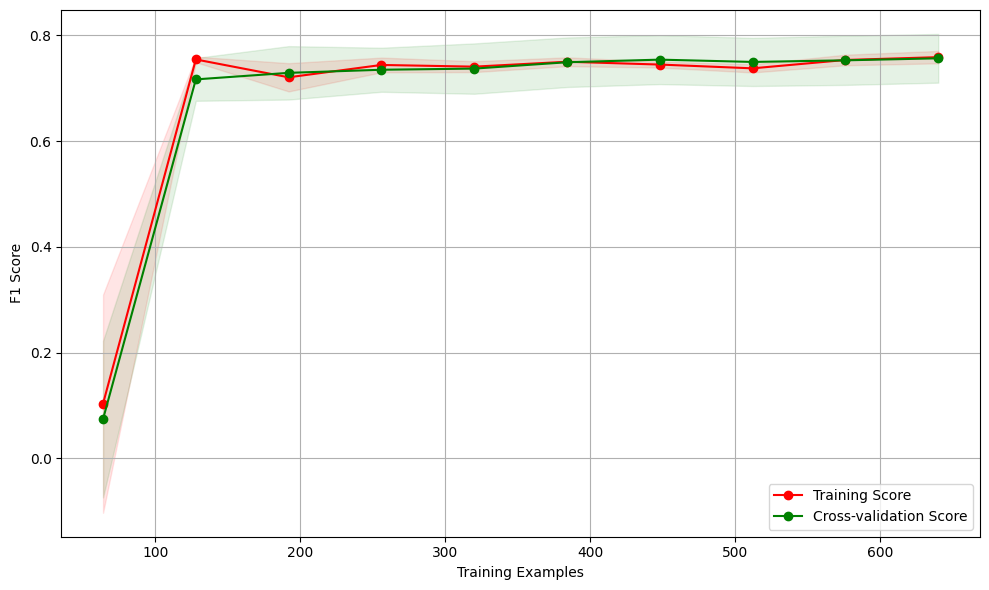

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve


plt.clf()
plt.close('all')
plt.rcdefaults()

# Calculate learning curve data
train_sizes, train_scores, val_scores = learning_curve(
    estimator=rf_best,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

# Calculate mean and standard deviation
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)


fig, ax = plt.subplots(figsize=(10, 6))

# Plotting with ax
ax.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training Score')
ax.plot(train_sizes, val_scores_mean, 'o-', color='g', label='Cross-validation Score')


ax.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color='r')
ax.fill_between(train_sizes, val_scores_mean - val_scores_std, val_scores_mean + val_scores_std, alpha=0.1, color='g')

ax.set_xlabel('Training Examples')
ax.set_ylabel('F1 Score')
ax.legend(loc='best')
ax.grid(True)

fig.tight_layout()


fig.savefig("learning_curve.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()


plt.close(fig)

In [79]:
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

# Extract best parameters for Logistic Regression from Strategy A
best_lr_params = strategy_a_results['Logistic Regression']['Best_Params']

# Remove 'model__' prefix from parameter keys
cleaned_lr_params = {key.replace('model__', ''): value for key, value in best_lr_params.items()}

# FIX: LR was trained with StandardScaler in Strategy A (lr_pipeline_a),
# so the baseline here must also use a scaler — otherwise the tuned
# hyperparameters (C, penalty, solver) are applied to raw unscaled data,
# unfairly weakening the LR baseline and biasing the McNemar comparison.
lr_baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, **cleaned_lr_params))
])
lr_baseline.fit(X_train, y_train)
y_pred_lr = lr_baseline.predict(X_test)

# Calculate correct and incorrect predictions for both models
xgb_correct = (y_pred == y_test)      # XGBoost (calibrated) predictions
lr_correct = (y_pred_lr == y_test)   # LR baseline predictions

# Construct the 2x2 contingency table
both_correct = np.sum(xgb_correct & lr_correct)
both_incorrect = np.sum(~xgb_correct & ~lr_correct)
xgb_only_correct = np.sum(xgb_correct & ~lr_correct)
lr_only_correct = np.sum(~xgb_correct & lr_correct)

contingency_table = [[both_correct, xgb_only_correct],
                     [lr_only_correct, both_incorrect]]

print("Contingency Table:")
print(np.array(contingency_table))

# Run McNemar's test (exact=True is correct here since discordant pairs are small)
result = mcnemar(contingency_table, exact=True)
print(f"\nMcNemar's test p-value: {result.pvalue:.4f}")

if result.pvalue < 0.05:
    print("There is a statistically significant difference between the two models.")
else:
    print("There is no statistically significant difference between the two models.")

Contingency Table:
[[153  11]
 [  4  33]]

McNemar's test p-value: 0.1185
There is no statistically significant difference between the two models.


Optimal threshold selected from training-set CV: 0.4109

Final Test-Set Evaluation:
              precision    recall  f1-score   support

           0       0.87      0.83      0.85       122
           1       0.75      0.81      0.78        79

    accuracy                           0.82       201
   macro avg       0.81      0.82      0.81       201
weighted avg       0.82      0.82      0.82       201


Confusion Matrix:
[[101  21]
 [ 15  64]]


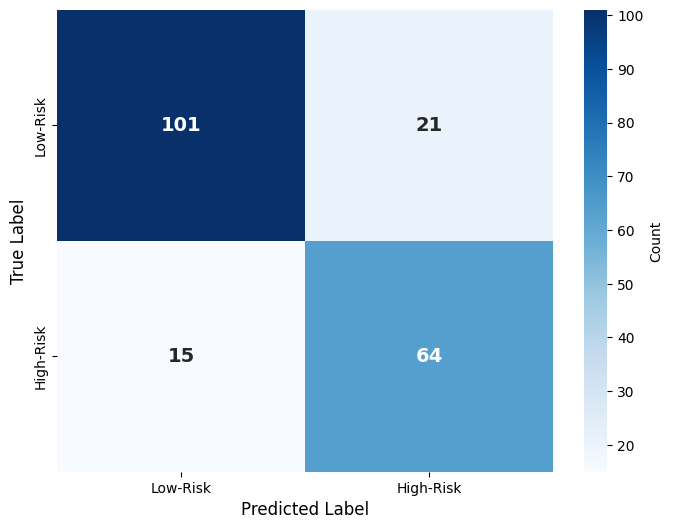


Confusion Matrix Metrics:
TN (True Negative): 101
FP (False Positive): 21
FN (False Negative): 15
TP (True Positive): 64

Sensitivity: 0.810
Specificity: 0.828
Precision: 0.753
NPV: 0.871
Accuracy: 0.821
F1-Score: 0.780


In [80]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_curve, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.clf()
plt.close("all")
plt.rcdefaults()


# Step 1: 5-Fold CV on TRAINING data only


cv_thresh = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_model = CalibratedClassifierCV(
    estimator=best_estimator,
    cv=5,
    method='isotonic'
)

oof_proba = cross_val_predict(
    oof_model,
    X_train,
    y_train,
    cv=cv_thresh,
    method='predict_proba',
    n_jobs=-1
)[:, 1]


# Step 2: Find Youden's J threshold from OOF predictions


fpr_oof, tpr_oof, thresholds_oof = roc_curve(
    y_train,
    oof_proba
)

j_scores_oof = tpr_oof - fpr_oof
optimal_idx_oof = np.argmax(j_scores_oof)
optimal_threshold = thresholds_oof[optimal_idx_oof]

print(
    f"Optimal threshold selected from training-set CV: "
    f"{optimal_threshold:.4f}"
)


# Step 3: Fit calibrated model on FULL training set


calibrated_model = CalibratedClassifierCV(
    estimator=best_estimator,
    cv=5,
    method='isotonic'
)
calibrated_model.fit(X_train, y_train)


# Step 4: Apply FIXED threshold to untouched TEST set


y_proba = calibrated_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= optimal_threshold).astype(int)

print("\nFinal Test-Set Evaluation:")
print(classification_report(y_test, y_pred))


# Step 5: Confusion Matrix


cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


# Step 6: Visualize Confusion Matrix


fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Low-Risk', 'High-Risk'],
            yticklabels=['Low-Risk', 'High-Risk'],
            cbar_kws={'label': 'Count'},
            annot_kws={'size': 14, 'weight': 'bold'})

ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)

fig.patch.set_facecolor('white')
plt.savefig('Figure_2A_Confusion_Matrix.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close(fig)

# ============================================================
# Step 7: Extract metrics from Confusion Matrix
# ============================================================

tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision = tp / (tp + fp)
npv = tn / (tn + fn)
accuracy = (tp + tn) / (tp + tn + fp + fn)
f1 = 2 * (precision * sensitivity) / (precision + sensitivity)

print(f"\n{'='*50}")
print(f"Confusion Matrix Metrics:")
print(f"{'='*50}")
print(f"TN (True Negative): {tn}")
print(f"FP (False Positive): {fp}")
print(f"FN (False Negative): {fn}")
print(f"TP (True Positive): {tp}")
print(f"\nSensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"Precision: {precision:.3f}")
print(f"NPV: {npv:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"F1-Score: {f1:.3f}")

In [81]:
# Nested Cross-Validation Robustness Check


from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import f1_score, roc_auc_score
from xgboost import XGBClassifier
import time

start_time = time.time()

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_train_reset = X_train.reset_index(drop=True)
y_train_reset = y_train.reset_index(drop=True)

nested_f1_scores = []
nested_auc_scores = []

for fold_idx, (tr_idx, val_idx) in enumerate(outer_cv.split(X_train_reset, y_train_reset), start=1):

    X_outer_train, X_outer_val = X_train_reset.iloc[tr_idx], X_train_reset.iloc[val_idx]
    y_outer_train, y_outer_val = y_train_reset.iloc[tr_idx], y_train_reset.iloc[val_idx]

    # Recompute scale_pos_weight using ONLY the outer-training fold (no leakage from val fold)
    counts = y_outer_train.value_counts()
    fold_scale_pos_weight = counts[0] / counts[1]

    inner_xgb_model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42
    )

    # scale_pos_weight to this fold's own class ratio

    inner_param_grid = dict(param_grid_xgb)
    inner_param_grid['scale_pos_weight'] = [fold_scale_pos_weight]

    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    inner_search = RandomizedSearchCV(
        estimator=inner_xgb_model,
        param_distributions=inner_param_grid,
        n_iter=20,

        scoring='f1',
        cv=inner_cv,
        random_state=42,
        n_jobs=-1,
        error_score='raise'
    )
    inner_search.fit(X_outer_train, y_outer_train)

    best_fold_model = inner_search.best_estimator_
    y_val_pred = best_fold_model.predict(X_outer_val)
    y_val_proba = best_fold_model.predict_proba(X_outer_val)[:, 1]

    fold_f1 = f1_score(y_outer_val, y_val_pred)
    fold_auc = roc_auc_score(y_outer_val, y_val_proba)

    nested_f1_scores.append(fold_f1)
    nested_auc_scores.append(fold_auc)

    print(f"Outer fold {fold_idx}: F1 = {fold_f1:.4f}, ROC-AUC = {fold_auc:.4f}")
    print(f"    best inner params: {inner_search.best_params_}")

nested_f1_scores = np.array(nested_f1_scores)
nested_auc_scores = np.array(nested_auc_scores)

print("\n=== Nested CV Results (XGBoost, Class Weighting) ===")
print(f"Nested outer-CV F1:      {nested_f1_scores.mean():.4f} (+/- {nested_f1_scores.std():.4f})")
print(f"Nested outer-CV ROC-AUC: {nested_auc_scores.mean():.4f} (+/- {nested_auc_scores.std():.4f})")

print("\n=== Comparison to Non-Nested Estimate (Table 1) ===")
print(f"Non-nested CV F1:      {best_cv_metrics['Mean_F1']:.4f}")
print(f"Non-nested CV ROC-AUC: {best_cv_metrics['Mean_ROC_AUC']:.4f}")

f1_gap = best_cv_metrics['Mean_F1'] - nested_f1_scores.mean()
auc_gap = best_cv_metrics['Mean_ROC_AUC'] - nested_auc_scores.mean()

print(f"\nEstimated optimistic bias (F1):      {f1_gap:+.4f}")
print(f"Estimated optimistic bias (ROC-AUC): {auc_gap:+.4f}")

elapsed = time.time() - start_time
print(f"\nElapsed time: {elapsed/60:.1f} minutes")

Outer fold 1: F1 = 0.7218, ROC-AUC = 0.8537
    best inner params: {'subsample': 0.6, 'scale_pos_weight': np.float64(1.56), 'reg_lambda': 10.0, 'reg_alpha': 0.01, 'objective': 'binary:logistic', 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.005, 'colsample_bytree': 0.6}
Outer fold 2: F1 = 0.7576, ROC-AUC = 0.8781
    best inner params: {'subsample': 0.7, 'scale_pos_weight': np.float64(1.564), 'reg_lambda': 0.5, 'reg_alpha': 0, 'objective': 'binary:logistic', 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.005, 'colsample_bytree': 0.6}
Outer fold 3: F1 = 0.7368, ROC-AUC = 0.8604
    best inner params: {'subsample': 0.6, 'scale_pos_weight': np.float64(1.564), 'reg_lambda': 10.0, 'reg_alpha': 0.01, 'objective': 'binary:logistic', 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.005, 'colsample_bytree': 0.6}
Outer fold 4: F1 = 0.7597, ROC-AUC = 0.8688
    best inner params: {'subsample': 0.7, 'sca

In [82]:
from sklearn.metrics import roc_curve, confusion_matrix

# Sensitivity-constrained threshold from OOF predictions (training set)


fpr_s, tpr_s, thresholds_s = roc_curve(y_train, oof_proba)

# constraint: sensitivity (tpr) >= 0.90

valid = tpr_s >= 0.90
best_idx = np.argmax(1 - fpr_s[valid])
sens_threshold = thresholds_s[valid][best_idx]

print(f"Sensitivity-constrained threshold (from training-set OOF): {sens_threshold:.4f}")



y_pred_sens = (y_proba >= sens_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_sens).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
ppv = tp / (tp + fp)
npv = tn / (tn + fn)

print(f"\nSensitivity-Constrained Threshold Results (Test Set):")
print(f"Threshold: {sens_threshold:.4f}")
print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"PPV: {ppv:.3f}")
print(f"NPV: {npv:.3f}")

print(f"\nFor comparison, Youden's J threshold was: {optimal_threshold:.4f}")

Sensitivity-constrained threshold (from training-set OOF): 0.2076

Sensitivity-Constrained Threshold Results (Test Set):
Threshold: 0.2076
Sensitivity: 0.924
Specificity: 0.713
PPV: 0.676
NPV: 0.935

For comparison, Youden's J threshold was: 0.4109


In [83]:
print(best_model_name, best_strategy)
print(best_cv_metrics['Mean_F1'], best_cv_metrics['Mean_ROC_AUC'])

XGBoost Class Weighting
0.7535052353800807 0.8704566377962475


In [84]:
print("OOF-based Youden threshold (this run):", optimal_threshold)
print("Number of OOF samples:", len(oof_proba))
print("OOF proba range:", oof_proba.min(), oof_proba.max())

OOF-based Youden threshold (this run): 0.4109358310699463
Number of OOF samples: 801
OOF proba range: 0.0 1.0


In [85]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import numpy as np
import pandas as pd

X_score = df['New_Total_Risk'].values.reshape(-1, 1)

# --- Internal validity indices across K = 2 to 6 ---
validity_results = []
for k in range(2, 7):
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km_k.fit_predict(X_score)
    validity_results.append({
        'K': k,
        'Silhouette': silhouette_score(X_score, labels_k),
        'Calinski_Harabasz': calinski_harabasz_score(X_score, labels_k),
        'Davies_Bouldin': davies_bouldin_score(X_score, labels_k),
        'Inertia': km_k.inertia_
    })

validity_df = pd.DataFrame(validity_results)
print("=== Cluster Validity Indices Across K ===")
print(validity_df.to_string(index=False))

# --- Gap statistic ---
def gap_statistic(X, k_max=6, n_refs=20, random_state=42):
    rng = np.random.default_rng(random_state)
    gaps = []
    for k in range(1, k_max + 1):
        km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
        real_disp = np.log(km.inertia_)
        ref_disps = []
        for _ in range(n_refs):
            X_ref = rng.uniform(X.min(), X.max(), size=X.shape)
            km_ref = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_ref)
            ref_disps.append(np.log(km_ref.inertia_))
        gap = np.mean(ref_disps) - real_disp
        gaps.append({'K': k, 'Gap': gap, 'Ref_std': np.std(ref_disps)})
    return pd.DataFrame(gaps)

gap_df = gap_statistic(X_score, k_max=6)
print("\n=== Gap Statistic ===")
print(gap_df.to_string(index=False))

# --- Bootstrap stability at K=2 ---
from sklearn.metrics import adjusted_rand_score

def bootstrap_stability(X, k=2, n_boot=100, random_state=42):
    rng = np.random.default_rng(random_state)
    base_labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
    ari_scores = []
    for _ in range(n_boot):
        idx = rng.choice(len(X), size=len(X), replace=True)
        boot_km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X[idx])
        boot_labels_full = boot_km.predict(X)
        ari_scores.append(adjusted_rand_score(base_labels, boot_labels_full))
    return np.mean(ari_scores), np.std(ari_scores)

stability_mean, stability_std = bootstrap_stability(X_score, k=2, n_boot=100)
print(f"\n=== K=2 Bootstrap Stability ===")
print(f"Mean ARI: {stability_mean:.4f} (+/- {stability_std:.4f})")

=== Cluster Validity Indices Across K ===
 K  Silhouette  Calinski_Harabasz  Davies_Bouldin     Inertia
 2    0.681691        3671.386360        0.438676 3558.819262
 3    0.620044        4265.580673        0.508157 1742.677226
 4    0.619607        5407.873525        0.505688  963.403557
 5    0.629888        6424.355341        0.484892  620.906731
 6    0.651333        7558.090822        0.515645  426.904744

=== Gap Statistic ===
 K      Gap  Ref_std
 1 0.120150 0.023776
 2 0.277641 0.027525
 3 0.177426 0.027677
 4 0.187975 0.023994
 5 0.176474 0.023238
 6 0.178331 0.024871

=== K=2 Bootstrap Stability ===
Mean ARI: 1.0000 (+/- 0.0000)


In [86]:
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix

n_boot = 2000
rng = np.random.default_rng(42)
n_test = len(y_test)

y_test_arr = np.asarray(y_test)
metrics_boot = {'auc': [], 'sensitivity': [], 'specificity': [],
                 'ppv': [], 'npv': [], 'f1': [], 'accuracy': []}

for _ in range(n_boot):
    idx = rng.choice(n_test, size=n_test, replace=True)
    yt, yp, ypr = y_test_arr[idx], y_pred[idx], y_proba[idx]

    if len(np.unique(yt)) < 2:
        continue

    tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()

    metrics_boot['auc'].append(roc_auc_score(yt, ypr))
    metrics_boot['sensitivity'].append(tp / (tp + fn) if (tp + fn) > 0 else np.nan)
    metrics_boot['specificity'].append(tn / (tn + fp) if (tn + fp) > 0 else np.nan)
    metrics_boot['ppv'].append(tp / (tp + fp) if (tp + fp) > 0 else np.nan)
    metrics_boot['npv'].append(tn / (tn + fn) if (tn + fn) > 0 else np.nan)
    metrics_boot['f1'].append(f1_score(yt, yp))
    metrics_boot['accuracy'].append((tp + tn) / n_test)

print("=== Bootstrap 95% CIs (test set, n_boot=2000) ===")
for name, vals in metrics_boot.items():
    vals = np.array(vals)
    point = vals.mean()
    lower, upper = np.percentile(vals, [2.5, 97.5])
    print(f"{name:12s}: {point:.4f}  (95% CI: {lower:.4f} - {upper:.4f})")

=== Bootstrap 95% CIs (test set, n_boot=2000) ===
auc         : 0.9107  (95% CI: 0.8716 - 0.9443)
sensitivity : 0.8101  (95% CI: 0.7231 - 0.8919)
specificity : 0.8274  (95% CI: 0.7600 - 0.8915)
ppv         : 0.7538  (95% CI: 0.6585 - 0.8438)
npv         : 0.8698  (95% CI: 0.8049 - 0.9273)
f1          : 0.7799  (95% CI: 0.7052 - 0.8447)
accuracy    : 0.8205  (95% CI: 0.7662 - 0.8706)


In [87]:
import statsmodels.api as sm
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

def calibration_slope_intercept(y_true, y_prob, eps=1e-6):
    y_prob_clipped = np.clip(y_prob, eps, 1 - eps)
    logit_p = np.log(y_prob_clipped / (1 - y_prob_clipped))
    X = sm.add_constant(logit_p)
    model = sm.Logit(y_true, X).fit(disp=0)
    intercept, slope = model.params
    return slope, intercept

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n = len(y_true)
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask = (y_prob >= lo) & (y_prob < hi) if i < n_bins - 1 else (y_prob >= lo) & (y_prob <= hi)
        if mask.sum() == 0:
            continue
        bin_acc = y_true[mask].mean()
        bin_conf = y_prob[mask].mean()
        ece += (mask.sum() / n) * abs(bin_acc - bin_conf)
    return ece



y_test_arr = np.asarray(y_test)
slope_post, intercept_post = calibration_slope_intercept(y_test_arr, y_proba)
ece_post = expected_calibration_error(y_test_arr, y_proba)
brier_post = brier_score_loss(y_test_arr, y_proba)

print("=== Post-Isotonic-Calibration (final reported model) ===")
print(f"Calibration slope:     {slope_post:.4f}  (ideal = 1.0)")
print(f"Calibration intercept: {intercept_post:.4f}  (ideal = 0.0)")
print(f"Expected Calibration Error (ECE): {ece_post:.4f}")
print(f"Brier score: {brier_post:.4f}")

# --- Pre-calibration (raw XGBoost probabilities, for comparison) ---

y_proba_raw = best_estimator.predict_proba(X_test)[:, 1]
slope_pre, intercept_pre = calibration_slope_intercept(y_test_arr, y_proba_raw)
ece_pre = expected_calibration_error(y_test_arr, y_proba_raw)
brier_pre = brier_score_loss(y_test_arr, y_proba_raw)

print("\n=== Pre-Isotonic-Calibration (raw model probabilities) ===")
print(f"Calibration slope:     {slope_pre:.4f}")
print(f"Calibration intercept: {intercept_pre:.4f}")
print(f"Expected Calibration Error (ECE): {ece_pre:.4f}")
print(f"Brier score: {brier_pre:.4f}")

=== Post-Isotonic-Calibration (final reported model) ===
Calibration slope:     0.7841  (ideal = 1.0)
Calibration intercept: -0.1376  (ideal = 0.0)
Expected Calibration Error (ECE): 0.0375
Brier score: 0.1191

=== Pre-Isotonic-Calibration (raw model probabilities) ===
Calibration slope:     4.9559
Calibration intercept: -0.4744
Expected Calibration Error (ECE): 0.2222
Brier score: 0.1882


In [88]:
sensitivity = 0.810
specificity = 0.828

LR_positive = sensitivity / (1 - specificity)
LR_negative = (1 - sensitivity) / specificity

print(f"LR+ : {LR_positive:.2f}")
print(f"LR- : {LR_negative:.2f}")

LR+ : 4.71
LR- : 0.23


In [89]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score

hier = AgglomerativeClustering(n_clusters=2, linkage='ward')
hier_labels = hier.fit_predict(df['New_Total_Risk'].values.reshape(-1, 1))

ari_with_kmeans = adjusted_rand_score(df['CKD_Risk_Binary'], hier_labels)
print(f"ARI between K-Means and Hierarchical (Ward) labels: {ari_with_kmeans:.4f}")

ARI between K-Means and Hierarchical (Ward) labels: 0.4897


In [90]:
# Hierarchical (Ward) Clustering: Group Sizes + Bootstrap Stability

import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score

X_score = df['New_Total_Risk'].values.reshape(-1, 1)

# ---- 1. Group sizes for the hierarchical (Ward) solution

hier_sizes = pd.Series(hier_labels).value_counts().sort_index()
print("Hierarchical (Ward) cluster sizes (raw labels, order not yet aligned to risk):")
print(hier_sizes)

# mean composite score per cluster (same convention as K-Means/GMM)

hier_means = pd.Series(X_score.flatten()).groupby(hier_labels).mean()
order = hier_means.sort_values().index.tolist()
remap_hier = {old: new for new, old in enumerate(order)}
hier_labels_aligned = np.vectorize(remap_hier.get)(hier_labels)

hier_sizes_aligned = pd.Series(hier_labels_aligned).value_counts().sort_index()
print("\nHierarchical (Ward) cluster sizes (aligned: 0=Low-Risk, 1=High-Risk):")
print(hier_sizes_aligned)

# ---- 2. Bootstrap stability of the hierarchical solution

def bootstrap_stability_hier(X, base_labels, n_boot=100, random_state=42):
    rng = np.random.default_rng(random_state)
    n = len(X)
    ari_scores = []
    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        boot_model = AgglomerativeClustering(n_clusters=2, linkage='ward')
        boot_labels = boot_model.fit_predict(X[idx])
        ari_scores.append(adjusted_rand_score(base_labels[idx], boot_labels))
    return np.mean(ari_scores), np.std(ari_scores)

hier_stability_mean, hier_stability_std = bootstrap_stability_hier(
    X_score, hier_labels_aligned, n_boot=100
)
print(f"\n=== Hierarchical (Ward) Bootstrap Stability (n_boot=100) ===")
print(f"Mean ARI: {hier_stability_mean:.4f} (+/- {hier_stability_std:.4f})")

# ---- 3. Summary row for Table 3.3 ----

print("\n=== Table 3.3 summary values ===")
print(f"Hierarchical (Ward): ARI vs K-Means = {ari_with_kmeans:.4f} (already computed earlier)")
print(f"Hierarchical (Ward): Bootstrap stability = {hier_stability_mean:.3f} ± {hier_stability_std:.3f}")
print(f"Hierarchical (Ward): Low-Risk n = {hier_sizes_aligned.get(0, 'NA')}, "
      f"High-Risk n = {hier_sizes_aligned.get(1, 'NA')}")

Hierarchical (Ward) cluster sizes (raw labels, order not yet aligned to risk):
0    758
1    244
Name: count, dtype: int64

Hierarchical (Ward) cluster sizes (aligned: 0=Low-Risk, 1=High-Risk):
0    758
1    244
Name: count, dtype: int64

=== Hierarchical (Ward) Bootstrap Stability (n_boot=100) ===
Mean ARI: 0.7359 (+/- 0.2352)

=== Table 3.3 summary values ===
Hierarchical (Ward): ARI vs K-Means = 0.4897 (already computed earlier)
Hierarchical (Ward): Bootstrap stability = 0.736 ± 0.235
Hierarchical (Ward): Low-Risk n = 758, High-Risk n = 244


In [91]:
mismatch = df['CKD_Risk_Binary'] != hier_labels
print(df.loc[mismatch, 'New_Total_Risk'].describe())
print(df['New_Total_Risk'].describe())

count    148.000000
mean       8.060811
std        0.801583
min        7.000000
25%        7.000000
50%        8.000000
75%        9.000000
max        9.000000
Name: New_Total_Risk, dtype: float64
count    1002.000000
mean        5.727545
std         4.075293
min         0.000000
25%         2.000000
50%         5.000000
75%         9.000000
max        15.000000
Name: New_Total_Risk, dtype: float64


In [92]:
# RISK-LABEL SENSITIVITY ANALYSIS: Gaussian Mixture Model (GMM)

from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score
from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier

X_score = df['New_Total_Risk'].values.reshape(-1, 1)


# ---- 1. Fit a 2-component GMM on the composite risk score ----

gmm = GaussianMixture(n_components=2, random_state=42, n_init=10)
gmm_labels_raw = gmm.fit_predict(X_score)

means = gmm.means_.flatten()
order = np.argsort(means)
remap_gmm = {old: new for new, old in enumerate(order)}
df['GMM_Risk_Binary'] = np.vectorize(remap_gmm.get)(gmm_labels_raw)

print("GMM component means (sorted, Low -> High):", np.sort(means))
print("GMM cluster sizes:", df['GMM_Risk_Binary'].value_counts().sort_index().to_dict())


# ---- 2. Participant-assignment agreement: K-Means vs. GMM

ari_km_gmm = adjusted_rand_score(df['CKD_Risk_Binary'], df['GMM_Risk_Binary'])
print(f"\nARI (K-Means vs. GMM): {ari_km_gmm:.4f}")

crosstab_km_gmm = pd.crosstab(
    df['CKD_Risk_Binary'], df['GMM_Risk_Binary'],
    rownames=['K-Means'], colnames=['GMM']
)
print("\nCross-tabulation (K-Means vs. GMM):")
print(crosstab_km_gmm)

mismatch_gmm = df['CKD_Risk_Binary'] != df['GMM_Risk_Binary']
print(f"\nParticipants relabeled under GMM: {mismatch_gmm.sum()} / {len(df)} "
      f"({100*mismatch_gmm.mean():.1f}%)")
print("\nComposite score distribution among relabeled participants:")
print(df.loc[mismatch_gmm, 'New_Total_Risk'].describe())
print("\nComposite score distribution, full sample:")
print(df['New_Total_Risk'].describe())

# ---- 3. Bootstrap stability of the GMM

def bootstrap_stability_gmm(X, n_boot=100, random_state=42):
    rng = np.random.default_rng(random_state)
    base = GaussianMixture(n_components=2, random_state=42, n_init=10).fit(X)
    base_labels = base.predict(X)
    ari_scores = []
    for _ in range(n_boot):
        idx = rng.choice(len(X), size=len(X), replace=True)
        boot_gmm = GaussianMixture(n_components=2, random_state=42, n_init=10).fit(X[idx])
        boot_labels_full = boot_gmm.predict(X)
        ari_scores.append(adjusted_rand_score(base_labels, boot_labels_full))
    return np.mean(ari_scores), np.std(ari_scores)

gmm_stability_mean, gmm_stability_std = bootstrap_stability_gmm(X_score, n_boot=100)
print(f"\n=== GMM Bootstrap Stability (n_boot=100) ===")
print(f"Mean ARI: {gmm_stability_mean:.4f} (+/- {gmm_stability_std:.4f})")

# ---- 4. Downstream model performance using GMM-derived labels


y_train_gmm = df.loc[X_train.index, 'GMM_Risk_Binary']
y_test_gmm  = df.loc[X_test.index,  'GMM_Risk_Binary']

scale_pos_weight_gmm = (y_train_gmm == 0).sum() / (y_train_gmm == 1).sum()
print(f"\nscale_pos_weight (GMM labels): {scale_pos_weight_gmm:.3f} "
      f"(K-Means labels used {scale_pos_weight:.3f})")

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

model_gmm = XGBClassifier(
    scale_pos_weight=scale_pos_weight_gmm, eval_metric='logloss', random_state=42
)
scores_gmm = cross_validate(model_gmm, X_train, y_train_gmm, cv=cv, scoring=['f1', 'roc_auc'])

model_kmeans = XGBClassifier(
    scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42
)
scores_kmeans = cross_validate(model_kmeans, X_train, y_train, cv=cv, scoring=['f1', 'roc_auc'])

print(f"\n[K-Means-derived labels] F1      = {scores_kmeans['test_f1'].mean():.4f} ± {scores_kmeans['test_f1'].std():.4f}")
print(f"[K-Means-derived labels] ROC-AUC = {scores_kmeans['test_roc_auc'].mean():.4f} ± {scores_kmeans['test_roc_auc'].std():.4f}")
print(f"\n[GMM-derived labels]     F1      = {scores_gmm['test_f1'].mean():.4f} ± {scores_gmm['test_f1'].std():.4f}")
print(f"[GMM-derived labels]     ROC-AUC = {scores_gmm['test_roc_auc'].mean():.4f} ± {scores_gmm['test_roc_auc'].std():.4f}")

# ---- 5. Paired comparison across the 10 folds

from scipy.stats import ttest_rel, wilcoxon

for metric in ['test_f1', 'test_roc_auc']:
    diff = scores_gmm[metric] - scores_kmeans[metric]
    t_stat, p_t = ttest_rel(scores_gmm[metric], scores_kmeans[metric])
    w_stat, p_w = wilcoxon(scores_gmm[metric], scores_kmeans[metric])
    print(f"\n{metric}: mean diff (GMM - K-Means) = {diff.mean():.4f}")
    print(f"  paired t-test p = {p_t:.4f} | Wilcoxon p = {p_w:.4f}")

GMM component means (sorted, Low -> High): [ 2.85030613 10.09271364]
GMM cluster sizes: {0: 610, 1: 392}

ARI (K-Means vs. GMM): 1.0000

Cross-tabulation (K-Means vs. GMM):
GMM        0    1
K-Means          
0        610    0
1          0  392

Participants relabeled under GMM: 0 / 1002 (0.0%)

Composite score distribution among relabeled participants:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: New_Total_Risk, dtype: float64

Composite score distribution, full sample:
count    1002.000000
mean        5.727545
std         4.075293
min         0.000000
25%         2.000000
50%         5.000000
75%         9.000000
max        15.000000
Name: New_Total_Risk, dtype: float64

=== GMM Bootstrap Stability (n_boot=100) ===
Mean ARI: 0.9982 (+/- 0.0182)

scale_pos_weight (GMM labels): 1.559 (K-Means labels used 1.559)

[K-Means-derived labels] F1      = 0.6678 ± 0.0715
[K-Means-derived labels] ROC-AUC = 0.8413 ± 0.0397

[GMM-der

/usr/local/lib/python3.13/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se



test_f1: mean diff (GMM - K-Means) = 0.0000
  paired t-test p = nan | Wilcoxon p = 1.0000

test_roc_auc: mean diff (GMM - K-Means) = 0.0000
  paired t-test p = nan | Wilcoxon p = 1.0000


Cross-Tabulation of Predicted Risk Tiers vs Observed Class:
Observed class    Observed low-risk (0)  Observed high-risk (1)
Risk_Tier                                                      
Low (<0.3)                           93                       9
Medium (0.3–0.6)                     17                      15
High (>0.6)                          12                      55
Total N = 201


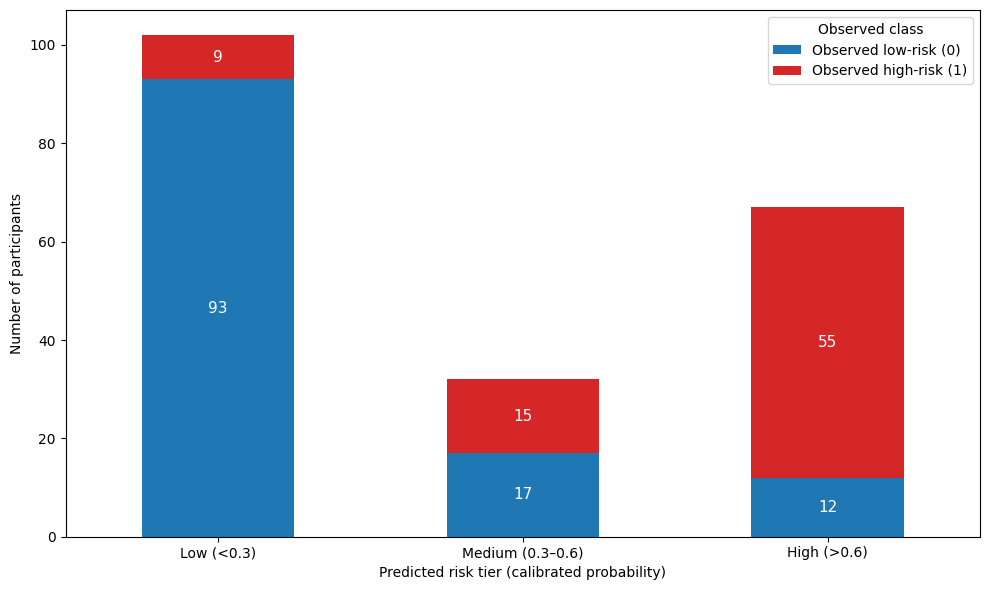

Saved fig6.png | pixels: (2970, 1769) | dpi: (299.9994, 299.9994)


In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.close("all")
plt.rcdefaults()

# Same tier boundaries as the original cell (0.3 and 0.6)
conditions = [
    (y_proba < 0.3),
    (y_proba >= 0.3) & (y_proba <= 0.6),
    (y_proba > 0.6),
]
tier_order = ["Low (<0.3)", "Medium (0.3\u20130.6)", "High (>0.6)"]
risk_tiers = np.select(conditions, tier_order, default="Unknown")

risk_df = pd.DataFrame({
    "Actual_Outcome": np.asarray(y_test),
    "Risk_Tier": pd.Categorical(risk_tiers, categories=tier_order, ordered=True),
})

# Clear, non-confusing names for the observed class (kept separate from the predicted tier names)
risk_df["Observed class"] = risk_df["Actual_Outcome"].map(
    {0: "Observed low-risk (0)", 1: "Observed high-risk (1)"}
)

cross_tab = pd.crosstab(risk_df["Risk_Tier"], risk_df["Observed class"])
cross_tab = cross_tab[["Observed low-risk (0)", "Observed high-risk (1)"]]
print("Cross-Tabulation of Predicted Risk Tiers vs Observed Class:")
print(cross_tab)
print("Total N =", int(cross_tab.values.sum()))

fig, ax = plt.subplots(figsize=(10, 6))
cross_tab.plot(kind="bar", stacked=True, color=["#1f77b4", "#d62728"], ax=ax)

# Count labels inside each bar segment
for container in ax.containers:
    labels = [str(int(v)) if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", color="white", fontsize=11)

ax.set_xlabel("Predicted risk tier (calibrated probability)")
ax.set_ylabel("Number of participants")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Observed class")

fig.tight_layout()

OUT_NAME = "fig6.png"
fig.savefig(OUT_NAME, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

from PIL import Image
img = Image.open(OUT_NAME)
print("Saved", OUT_NAME, "| pixels:", img.size, "| dpi:", img.info.get("dpi"))

**Global Feature Importance (SHAP)**

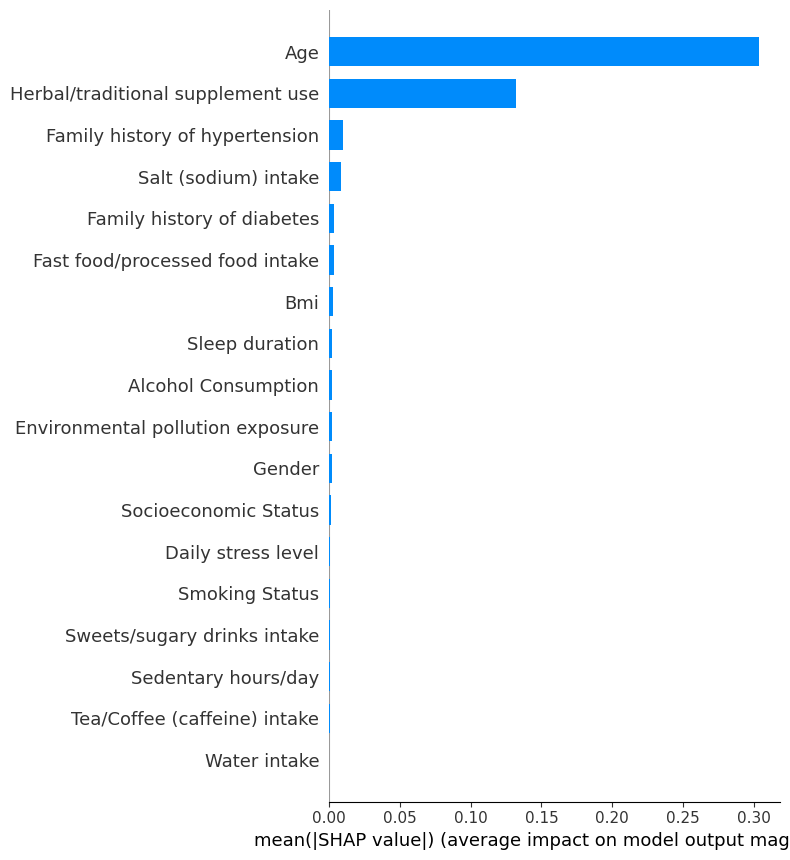

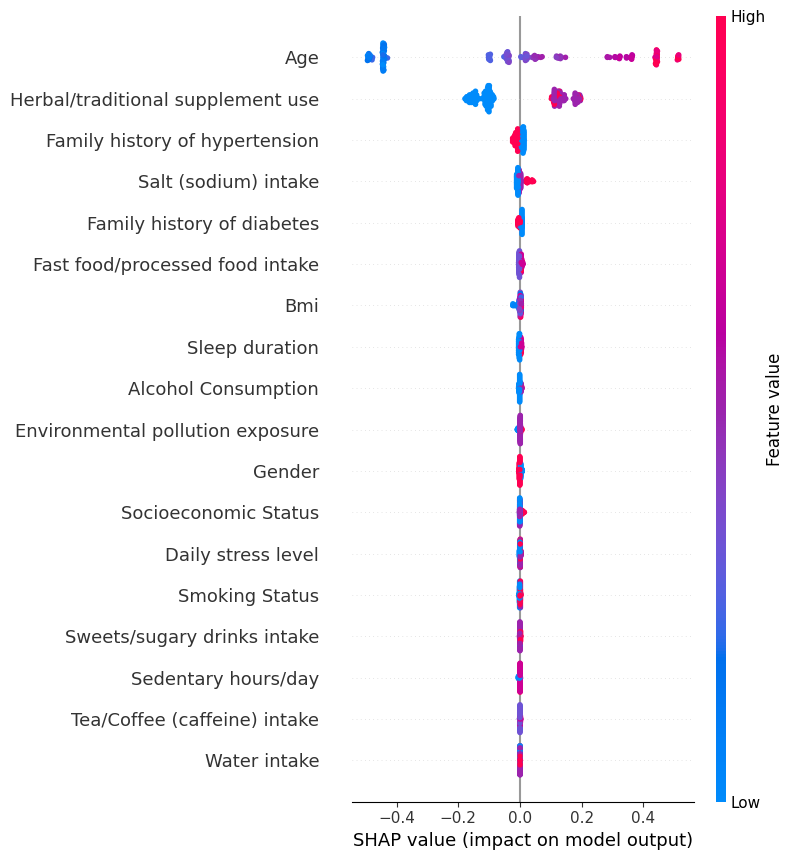

In [94]:
import shap
import matplotlib.pyplot as plt

shap.initjs()

# Fit the best base estimator on the full training set
rf_best.fit(X_train, y_train)

# Choose the right SHAP explainer based on model/pipeline type
def get_shap_explainer_and_values(estimator, X):
    """Return (explainer, shap_values_class1) for tree or linear models."""
    # Unwrap pipeline to get the underlying model
    from sklearn.pipeline import Pipeline as _P
    from imblearn.pipeline import Pipeline as _IP
    core = estimator
    X_transformed = X
    if isinstance(estimator, (_P, _IP)):
        # Apply all steps except the final estimator
        for name, step in estimator.steps[:-1]:
            if hasattr(step, 'transform'):
                X_transformed = step.transform(X_transformed)
        core = estimator.steps[-1][1]

    # Select explainer

    tree_types = ('RandomForestClassifier', 'XGBClassifier', 'LGBMClassifier',
                  'GradientBoostingClassifier', 'ExtraTreesClassifier')
    if type(core).__name__ in tree_types:
        explainer = shap.TreeExplainer(core)
        sv = explainer.shap_values(X_transformed)
        if hasattr(sv, '__len__') and len(sv) == 2 and not isinstance(sv, np.ndarray):
            sv_c1 = sv[1]
        elif isinstance(sv, np.ndarray) and sv.ndim == 3:
            sv_c1 = sv[:, :, 1]
        else:
            sv_c1 = sv
        return explainer, sv_c1, X_transformed
    else:

        try:
            explainer = shap.LinearExplainer(core, X_transformed)
            sv_c1 = explainer.shap_values(X_transformed)
        except Exception:
            background = shap.kmeans(X_transformed, 50)
            explainer = shap.KernelExplainer(core.predict_proba, background)
            sv_c1 = explainer.shap_values(X_transformed)[:, :, 1]
        return explainer, sv_c1, X_transformed

import numpy as np
explainer, shap_values_class1, X_test_transformed = get_shap_explainer_and_values(rf_best, X_test)

# Use transformed feature matrix for SHAP plots (same shape as shap_values_class1)
X_shap = pd.DataFrame(X_test_transformed, columns=X_test.columns) \
         if not isinstance(X_test_transformed, pd.DataFrame) else X_test_transformed


plt.figure()
shap.summary_plot(shap_values_class1, X_shap, plot_type='bar', show=False)
plt.show()

# SHAP beeswarm plot
plt.figure()
shap.summary_plot(shap_values_class1, X_shap, show=False)
#plt.title('SHAP Beeswarm Plot (Directional Impact)')
plt.show()

Top 3 most important features: ['Age', 'Herbal/traditional supplement use', 'Family history of hypertension']


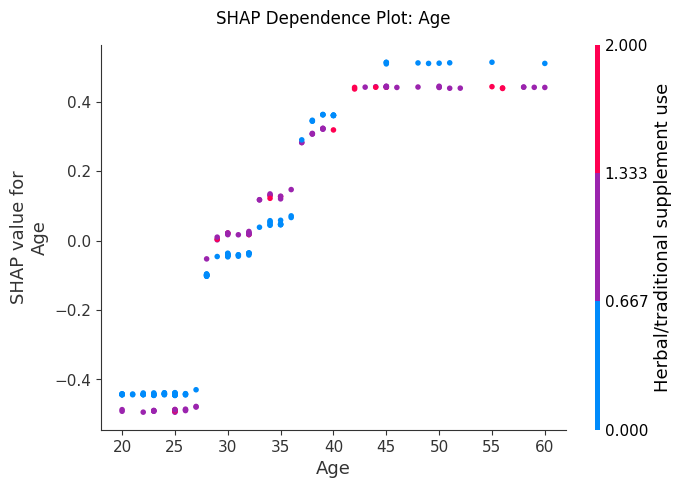

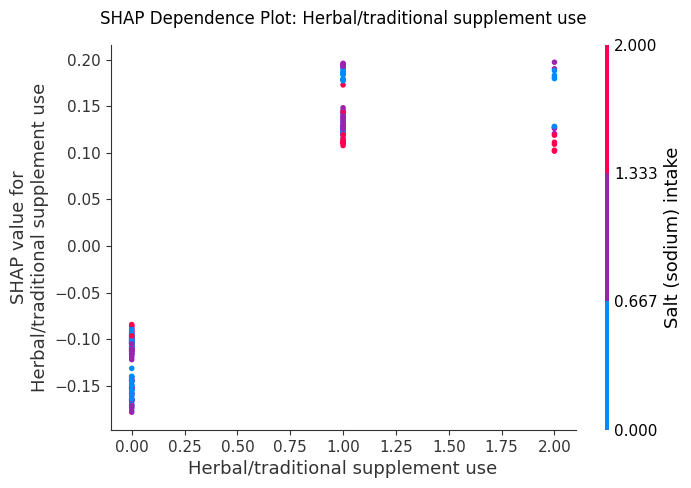

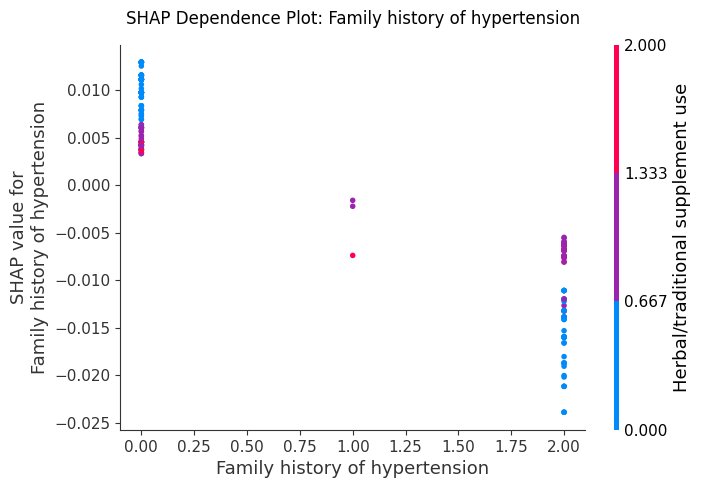

In [95]:
import re
import matplotlib.pyplot as plt
import numpy as np
import shap

plt.clf()
plt.close("all")
plt.rcdefaults()

# Mean absolute SHAP values
mean_abs_shap_values = np.abs(shap_values_class1).mean(axis=0)

# Top 3 features
top_3_indices = np.argsort(mean_abs_shap_values)[-3:][::-1]
top_3_features = X_shap.columns[top_3_indices].tolist()
print(f"Top 3 most important features: {top_3_features}")


for feature in top_3_features:

    plt.clf()
    plt.close("all")

    # SHAP dependence plot
    shap.dependence_plot(feature, shap_values_class1, X_shap, show=False)


    fig = plt.gcf()


    plt.title(f"SHAP Dependence Plot: {feature}", fontsize=12, pad=15)

    safe_feature_name = re.sub(r"[^\w\-]", "_", feature)
    filename = f"shap_dependence_{safe_feature_name}.svg"


    # Save figure as SVG
    #fig.savefig(filename, format="svg", bbox_inches="tight")
    #print(f"Successfully Saved: {filename}")

    plt.show()

    plt.close(fig)

**Local Explanations (Waterfall)**

Successfully Saved: shap_waterfall_Low_Risk_Individual___0_3_.svg


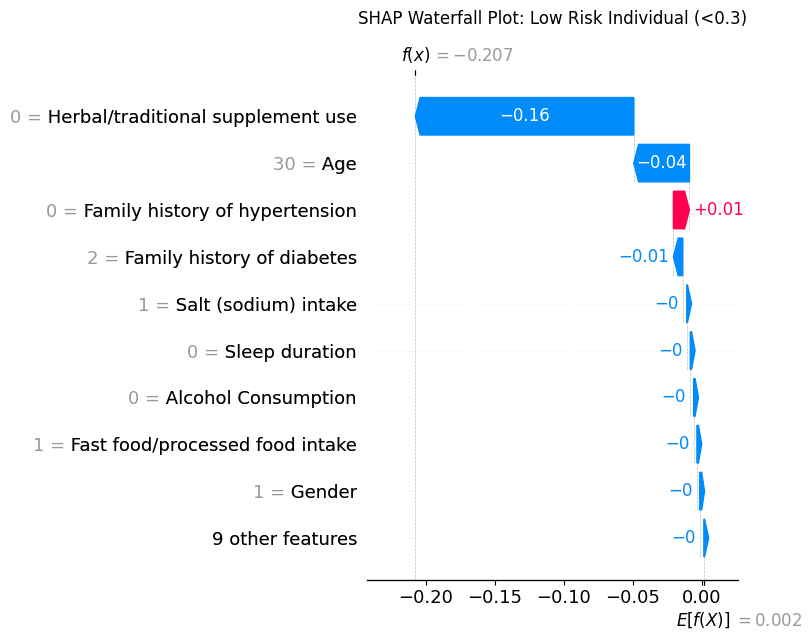

Successfully Saved: shap_waterfall_Medium_Risk_Individual__0_3-0_6_.svg


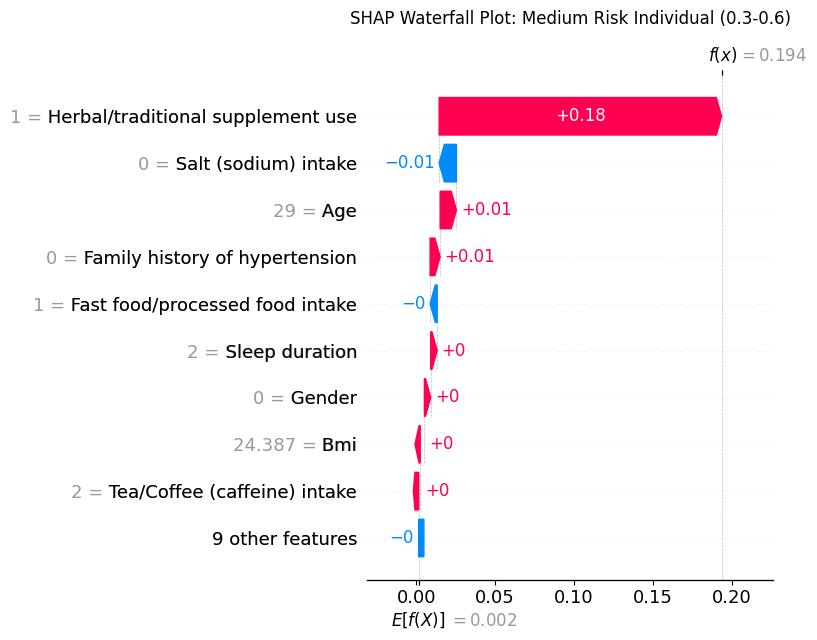

Successfully Saved: shap_waterfall_High_Risk_Individual___0_6_.svg


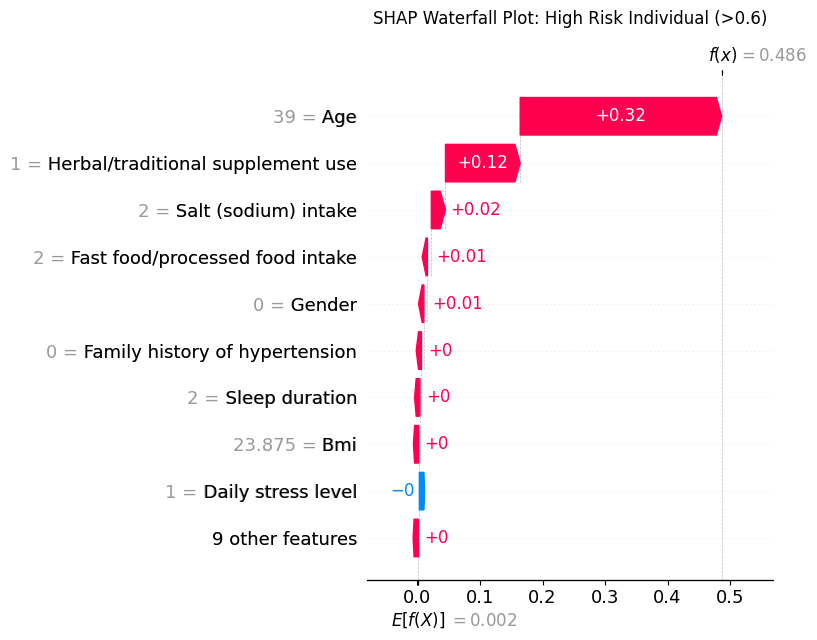

In [98]:
# Clear memory and reset defaults

plt.clf()
plt.close("all")
plt.rcdefaults()

# Find the integer position (iloc) of the first Individual in each risk tier

low_risk_iloc  = np.where(risk_df["Risk_Tier"] == "Low (<0.3)")[0][0]
med_risk_iloc  = np.where(risk_df["Risk_Tier"] == "Medium (0.3–0.6)")[0][0]
high_risk_iloc = np.where(risk_df["Risk_Tier"] == "High (>0.6)")[0][0]

patient_ilocs = {
    "Low Risk Individual (<0.3)": low_risk_iloc,
    "Medium Risk Individual (0.3-0.6)": med_risk_iloc,
    "High Risk Individual (>0.6)": high_risk_iloc,
}

# Extract base value for class 1 robustly

ev = explainer.expected_value
base_value = float(ev[1] if isinstance(ev, (list, np.ndarray)) else ev)

# Loop over risk tiers to plot and save

for title, iloc in patient_ilocs.items():
    # Clear figure and axis for each iteration
    plt.clf()
    plt.close("all")

    explanation = shap.Explanation(
        values=shap_values_class1[iloc],
        base_values=base_value,
        data=X_shap.iloc[iloc].values,
        feature_names=X_shap.columns.tolist(),
    )

    # Generate SHAP waterfall plot
    shap.plots.waterfall(explanation, show=False)

    # Get current figure handle
    fig = plt.gcf()

    # Add plot title
    plt.title(f"SHAP Waterfall Plot: {title}", fontsize=12, pad=15)
    plt.tight_layout()

    # Create a safe filename by replacing special characters (<, >, spaces, brackets)
    safe_title = re.sub(r"[^\w\-]", "_", title)
    filename = f"shap_waterfall_{safe_title}.svg"

    # Save figure as SVG
    fig.savefig(filename, format="svg", bbox_inches="tight")
    print(f"Successfully Saved: {filename}")

    plt.show()

    # Close figure after displaying
    plt.close(fig)

Successfully Saved: SHAP_Waterfall_Three_Risk_Tiers.png


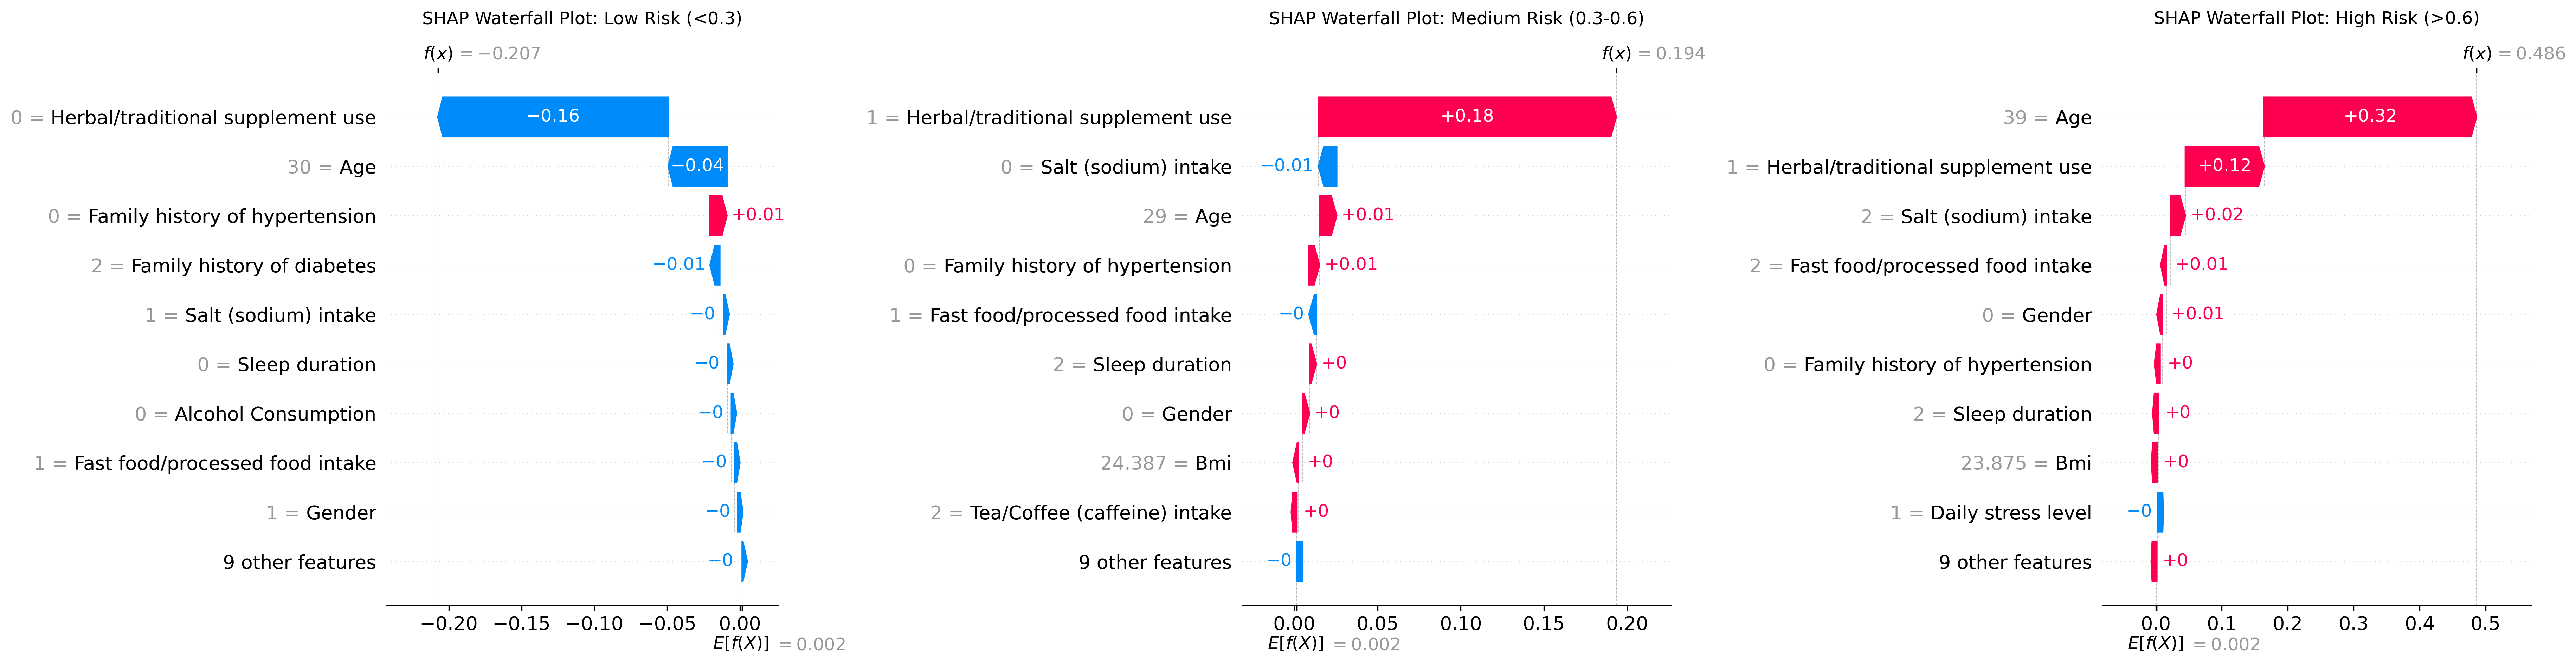

In [100]:
plt.close("all")
plt.rcdefaults()

tier_order = ["Low (<0.3)", "Medium (0.3–0.6)", "High (>0.6)"]

low_risk_iloc  = np.where(risk_df["Risk_Tier"] == tier_order[0])[0][0]
med_risk_iloc  = np.where(risk_df["Risk_Tier"] == tier_order[1])[0][0]
high_risk_iloc = np.where(risk_df["Risk_Tier"] == tier_order[2])[0][0]

patient_ilocs = {
    "Low Risk (<0.3)": low_risk_iloc,
    "Medium Risk (0.3-0.6)": med_risk_iloc,
    "High Risk (>0.6)": high_risk_iloc,
}


ev = explainer.expected_value

base_value = float(
    ev[1] if isinstance(ev, (list, np.ndarray)) else ev
)


figures = []

for title, iloc in patient_ilocs.items():

    explanation = shap.Explanation(
        values=shap_values_class1[iloc],
        base_values=base_value,
        data=X_shap.iloc[iloc].values,
        feature_names=X_shap.columns.tolist(),
    )

    # Create separate figure
    plt.figure(figsize=(8, 10))

    shap.plots.waterfall(
        explanation,
        show=False,
        max_display=10
    )

    plt.title(
        f"SHAP Waterfall Plot: {title}",
        fontsize=12,
        pad=15
    )

    plt.tight_layout()

    figures.append(plt.gcf())


temp_files = []

for i, fig in enumerate(figures):

    temp_file = f"temp_shap_{i}.png"

    fig.savefig(
        temp_file,
        dpi=300,
        bbox_inches="tight"
    )

    temp_files.append(temp_file)

    plt.close(fig)


# Combine 3 plots side by side


from PIL import Image

images = [Image.open(f) for f in temp_files]

# Find maximum height
max_height = max(img.height for img in images)

# Total width
total_width = sum(img.width for img in images)

# Create combined image
combined = Image.new(
    "RGB",
    (total_width, max_height),
    "white"
)


x_offset = 0

for img in images:

    combined.paste(img, (x_offset, 0))

    x_offset += img.width


# Save combined figure

combined.save(
    "SHAP_Waterfall_Three_Risk_Tiers.png",
    dpi=(300, 300)
)

print("Successfully Saved: SHAP_Waterfall_Three_Risk_Tiers.png")

# Display combined figure
display(combined)


# Remove temporary files

import os

for f in temp_files:
    if os.path.exists(f):
        os.remove(f)

**Local Patient Explanations (LIME)**

In [101]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283913 sha256=dfdc71c277318742140aabbd2fbd2b6fd0532c98dd0a7d71bae2e6de7f6e20a5
  Stored in directory: /root/.cache/pip/wheels/7c/04/5c/157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
Successfully built lime


In [102]:

# Select representative patients (one per risk tier) from X_test

X_test_reset = X_test.reset_index(drop=True)
y_proba_s = pd.Series(y_proba)  # y_proba = calibrated_model.predict_proba(X_test)[:,1]

def pick_representative(mask, label):
    sub = y_proba_s[mask]
    med = sub.median()
    idx = (sub - med).abs().idxmin()
    print(f"{label}: iloc={idx}, proba={y_proba_s[idx]:.4f}")
    return idx

low_mask  = y_proba_s < 0.30
med_mask  = (y_proba_s >= 0.30) & (y_proba_s <= 0.60)
high_mask = y_proba_s > 0.60

low_iloc  = pick_representative(low_mask,  "Low-Risk representative")
med_iloc  = pick_representative(med_mask,  "Medium-Risk representative")
high_iloc = pick_representative(high_mask, "High-Risk representative")

patients = {'Low-Risk': low_iloc, 'Medium-Risk': med_iloc, 'High-Risk': high_iloc}

Low-Risk representative: iloc=1, proba=0.0391
Medium-Risk representative: iloc=95, proba=0.4791
High-Risk representative: iloc=25, proba=0.8511


In [103]:
import shap

explainer_shap = shap.TreeExplainer(best_estimator)   # best_estimator = tuned XGBoost
shap_values = explainer_shap.shap_values(X_test_reset)

shap_top5 = {}
for label, iloc in patients.items():
    row_shap = shap_values[iloc]
    order = np.argsort(-np.abs(row_shap))[:5]
    top_feats = [X_test_reset.columns[i] for i in order]
    shap_top5[label] = top_feats
    print(f"SHAP top-5 for {label}: {top_feats}")

SHAP top-5 for Low-Risk: ['Age', 'Herbal/traditional supplement use', 'Family history of hypertension', 'Family history of diabetes', 'Environmental pollution exposure']
SHAP top-5 for Medium-Risk: ['Herbal/traditional supplement use', 'Age', 'Salt (sodium) intake', 'Family history of hypertension', 'Fast food/processed food intake']
SHAP top-5 for High-Risk: ['Age', 'Herbal/traditional supplement use', 'Salt (sodium) intake', 'Fast food/processed food intake', 'Gender']


In [104]:
import lime
import lime.lime_tabular

n_repeats = 50
lime_results = {}
fidelity_scores_per_run = {}

for label, iloc in patients.items():
    top5_per_run = []
    for run_i in range(n_repeats):
        explainer_lime = lime.lime_tabular.LimeTabularExplainer(
            training_data=np.array(X_train),
            feature_names=X_train.columns,
            class_names=['Low Risk', 'High Risk'],
            mode='classification',
            random_state=run_i
        )
        exp = explainer_lime.explain_instance(
            data_row=X_test_reset.iloc[iloc].values,
            predict_fn=calibrated_model.predict_proba,
            num_features=10
        )
        as_list = exp.as_list()
        fidelity_scores_per_run.setdefault(label, []).append(exp.score)
        top5 = [item[0] for item in as_list[:5]]
        top5_clean = []
        for cond in top5:
            for col in X_train.columns:
                if col in cond:
                    top5_clean.append(col)
                    break
        top5_per_run.append(top5_clean)
    lime_results[label] = top5_per_run
    print(f"LIME stability done for {label} ({n_repeats} runs)")
    print("\n=== LIME Local-Surrogate Fidelity (R²) ===")
    for label, scores in fidelity_scores_per_run.items():
      print(f"{label}: mean R² = {np.mean(scores):.3f} (min={np.min(scores):.3f}, max={np.max(scores):.3f})")



LIME stability done for Low-Risk (50 runs)

=== LIME Local-Surrogate Fidelity (R²) ===
Low-Risk: mean R² = 0.449 (min=0.432, max=0.463)
LIME stability done for Medium-Risk (50 runs)

=== LIME Local-Surrogate Fidelity (R²) ===
Low-Risk: mean R² = 0.449 (min=0.432, max=0.463)
Medium-Risk: mean R² = 0.156 (min=0.137, max=0.177)
LIME stability done for High-Risk (50 runs)

=== LIME Local-Surrogate Fidelity (R²) ===
Low-Risk: mean R² = 0.449 (min=0.432, max=0.463)
Medium-Risk: mean R² = 0.156 (min=0.137, max=0.177)
High-Risk: mean R² = 0.694 (min=0.673, max=0.712)


In [105]:
from collections import Counter
from itertools import combinations
import numpy as np

stability_summary = {}

for label, runs in lime_results.items():
    all_feats = [f for run in runs for f in run]
    freq = Counter(all_feats)
    total_runs = len(runs)
    freq_sorted = freq.most_common()

    print(f"\n--- {label} (n={total_runs} LIME runs) ---")
    for feat, cnt in freq_sorted[:8]:
        print(f"  {feat}: {cnt}/{total_runs} = {cnt/total_runs*100:.0f}%")

    consensus_top5 = [f for f, c in freq_sorted[:5]]
    stability_summary[label] = {'consensus_top5': consensus_top5}

    jaccards = []
    for i, j in combinations(range(total_runs), 2):
        a, b = set(runs[i]), set(runs[j])
        if len(a | b) == 0:
            continue
        jaccards.append(len(a & b) / len(a | b))
    mean_jaccard = sum(jaccards) / len(jaccards)
    stability_summary[label]['mean_jaccard'] = mean_jaccard
    print(f"  Mean pairwise Jaccard (LIME stability, 50 runs): {mean_jaccard:.3f}")

print("\n" + "="*60)
print("SHAP vs LIME AGREEMENT")
print("="*60)

overlaps, jaccs = [], []
for label in patients.keys():
    shap_set = set(shap_top5[label])
    lime_set = set(stability_summary[label]['consensus_top5'])
    overlap = shap_set & lime_set
    jaccard = len(overlap) / len(shap_set | lime_set)
    overlaps.append(len(overlap))
    jaccs.append(jaccard)
    print(f"\n{label}:")
    print(f"  SHAP top-5:  {sorted(shap_set)}")
    print(f"  LIME top-5:  {sorted(lime_set)}")
    print(f"  Overlap: {len(overlap)}/5 features, Jaccard={jaccard:.3f}")

print(f"\nAverage LIME stability (Jaccard): {np.mean([stability_summary[l]['mean_jaccard'] for l in patients]):.3f}")
print(f"Average SHAP-LIME overlap: {np.mean(overlaps):.1f}/5")
print(f"Average SHAP-LIME Jaccard agreement: {np.mean(jaccs):.3f}")


--- Low-Risk (n=50 LIME runs) ---
  Age: 50/50 = 100%
  Herbal/traditional supplement use: 50/50 = 100%
  Family history of hypertension: 34/50 = 68%
  Sedentary hours/day: 21/50 = 42%
  Fast food/processed food intake: 15/50 = 30%
  Environmental pollution exposure: 12/50 = 24%
  Sleep duration: 11/50 = 22%
  Sweets/sugary drinks intake: 10/50 = 20%
  Mean pairwise Jaccard (LIME stability, 50 runs): 0.430

--- Medium-Risk (n=50 LIME runs) ---
  Age: 50/50 = 100%
  Herbal/traditional supplement use: 50/50 = 100%
  Family history of hypertension: 21/50 = 42%
  Sleep duration: 19/50 = 38%
  Salt (sodium) intake: 16/50 = 32%
  Environmental pollution exposure: 14/50 = 28%
  Water intake: 13/50 = 26%
  Daily stress level: 12/50 = 24%
  Mean pairwise Jaccard (LIME stability, 50 runs): 0.389

--- High-Risk (n=50 LIME runs) ---
  Age: 50/50 = 100%
  Herbal/traditional supplement use: 50/50 = 100%
  Family history of hypertension: 44/50 = 88%
  Salt (sodium) intake: 32/50 = 64%
  Fast food/pr

In [106]:
perturb_delta = 1          # +/- 1 ordinal level, matches your encoding scheme
fixed_seed = 42            # seed held constant -> isolates input effect only

perturbation_results = {}

for label, iloc in patients.items():
    base_row = X_test_reset.iloc[iloc].copy()
    top5_features = stability_summary[label]['consensus_top5']

    row_records = []

    for feat in top5_features:
        feat_min = X_train[feat].min()
        feat_max = X_train[feat].max()

        for direction, delta in [('+1', perturb_delta), ('-1', -perturb_delta)]:
            perturbed_row = base_row.copy()
            new_val = perturbed_row[feat] + delta
            new_val = np.clip(new_val, feat_min, feat_max)

            # skip no-op perturbations (already at boundary)
            if new_val == perturbed_row[feat]:
                continue

            perturbed_row[feat] = new_val

            explainer_lime_p = lime.lime_tabular.LimeTabularExplainer(
                training_data=np.array(X_train),
                feature_names=X_train.columns,
                class_names=['Low Risk', 'High Risk'],
                mode='classification',
                random_state=fixed_seed
            )

            exp_p = explainer_lime_p.explain_instance(
                data_row=perturbed_row.values,
                predict_fn=calibrated_model.predict_proba,
                num_features=10
            )

            as_list_p = exp_p.as_list()
            top5_p_raw = [item[0] for item in as_list_p[:5]]
            top5_p_clean = []
            for cond in top5_p_raw:
                for col in X_train.columns:
                    if col in cond:
                        top5_p_clean.append(col)
                        break

            original_set = set(top5_features)
            perturbed_set = set(top5_p_clean)
            jaccard = len(original_set & perturbed_set) / len(original_set | perturbed_set)

            row_records.append({
                'Individual': label,
                'Perturbed_Feature': feat,
                'Direction': direction,
                'Original_Value': base_row[feat],
                'Perturbed_Value': new_val,
                'New_Top5': top5_p_clean,
                'Jaccard_vs_Original_Top5': jaccard
            })

    perturbation_results[label] = row_records
    print(f"\n--- {label} (individual): perturbation sensitivity ---")
    for r in row_records:
        print(f"  {r['Perturbed_Feature']} ({r['Direction']}): "
              f"Jaccard={r['Jaccard_vs_Original_Top5']:.3f}  "
              f"New top-5={r['New_Top5']}")

# ---- Summary table for the paper ----

all_rows = [r for rows in perturbation_results.values() for r in rows]
summary_df = pd.DataFrame(all_rows)

print("\n" + "=" * 60)
print("PERTURBATION-SENSITIVITY SUMMARY (mean Jaccard vs original top-5)")
print("=" * 60)
print(summary_df.groupby('Individual')['Jaccard_vs_Original_Top5'].agg(['mean', 'min', 'max']))
print(f"\nOverall mean Jaccard (perturbation robustness): "
      f"{summary_df['Jaccard_vs_Original_Top5'].mean():.3f}")

# Optional: save for direct use in the manuscript
summary_df.to_csv('lime_perturbation_sensitivity.csv', index=False)
print("\nSaved: lime_perturbation_sensitivity.csv")


--- Low-Risk (individual): perturbation sensitivity ---
  Age (+1): Jaccard=0.429  New top-5=['Age', 'Herbal/traditional supplement use', 'Family history of hypertension', 'Bmi', 'Water intake']
  Age (-1): Jaccard=0.667  New top-5=['Age', 'Herbal/traditional supplement use', 'Environmental pollution exposure', 'Family history of hypertension', 'Sedentary hours/day']
  Herbal/traditional supplement use (+1): Jaccard=0.667  New top-5=['Age', 'Herbal/traditional supplement use', 'Environmental pollution exposure', 'Family history of hypertension', 'Sedentary hours/day']
  Family history of hypertension (+1): Jaccard=0.667  New top-5=['Age', 'Herbal/traditional supplement use', 'Environmental pollution exposure', 'Family history of hypertension', 'Sedentary hours/day']
  Sedentary hours/day (-1): Jaccard=0.429  New top-5=['Age', 'Herbal/traditional supplement use', 'Environmental pollution exposure', 'Family history of hypertension', 'Tea/Coffee (caffeine) intake']
  Fast food/processed 

**Summary: Explainable AI (XAI) Analysis**

In [107]:
import pandas as pd
import numpy as np
import scipy.stats as stats

# Number of CV folds
n_splits = 10
t_multiplier = stats.t.ppf(0.975, df=n_splits - 1)

ci_records = []

def format_ci(mean, std):
    margin = t_multiplier * (std / np.sqrt(n_splits))
    lower = mean - margin
    upper = mean + margin
    return f"{mean:.3f} ({lower:.3f} - {upper:.3f})"

# ------------------------
# Strategy A
# ------------------------
for model_name, metrics in strategy_a_results.items():
    ci_records.append({
        'Model': model_name,
        'Strategy': 'Class Weighting',
        'F1 Macro (95% CI)': format_ci(metrics['Mean_F1'], metrics['Std_F1']),
        'ROC AUC (95% CI)': format_ci(metrics['Mean_ROC_AUC'], metrics['Std_ROC_AUC'])
    })

# ------------------------
# Strategy B
# ------------------------
for model_name, metrics in strategy_b_results.items():
    ci_records.append({
        'Model': model_name,
        'Strategy': 'SMOTE',
        'F1 Macro (95% CI)': format_ci(metrics['Mean_F1'], metrics['Std_F1']),
        'ROC AUC (95% CI)': format_ci(metrics['Mean_ROC_AUC'], metrics['Std_ROC_AUC'])
    })

ci_df = pd.DataFrame(ci_records)

display(ci_df)

,Model,Strategy,F1 Macro (95% CI),ROC AUC (95% CI)
0,Logistic Regression,Class Weighting,0.738 (0.702 - 0.775),0.875 (0.851 - 0.898)
1,Random Forest,Class Weighting,0.744 (0.709 - 0.780),0.873 (0.851 - 0.896)
2,XGBoost,Class Weighting,0.754 (0.718 - 0.789),0.870 (0.848 - 0.893)
3,SVM,Class Weighting,0.731 (0.690 - 0.772),0.869 (0.843 - 0.895)
4,LightGBM,Class Weighting,0.752 (0.717 - 0.788),0.874 (0.850 - 0.898)
5,Logistic Regression,SMOTE,0.722 (0.680 - 0.765),0.872 (0.845 - 0.898)
6,Random Forest,SMOTE,0.735 (0.704 - 0.766),0.872 (0.851 - 0.894)
7,XGBoost,SMOTE,0.750 (0.723 - 0.778),0.874 (0.853 - 0.894)
8,LightGBM,SMOTE,0.730 (0.687 - 0.773),0.866 (0.843 - 0.890)
9,SVM,SMOTE,0.719 (0.691 - 0.747),0.866 (0.852 - 0.879)


In [108]:
from sklearn.base import clone
from sklearn.model_selection import cross_validate, StratifiedKFold
from scipy.stats import ttest_rel, wilcoxon


# Same CV split used originally in RandomizedSearchCV (class weighting strategy)
cv_fixed = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = {'f1': 'f1', 'roc_auc': 'roc_auc'}

# --- Step 1: Re-run 10-fold CV with each model's ALREADY-TUNED hyperparameters ---
# (clone() strips fitted weights but keeps the tuned hyperparameters, so this
#  reproduces the exact same setup as Table 1 — just keeping fold-level scores this time)
fold_scores = {}
for model_name, metrics in strategy_a_results.items():
    est = clone(metrics['Best_Estimator'])
    cv_res = cross_validate(est, X_train, y_train, cv=cv_fixed, scoring=scoring, n_jobs=-1)
    fold_scores[model_name] = {'f1': cv_res['test_f1'], 'roc_auc': cv_res['test_roc_auc']}
    print(f"{model_name}: F1 mean={cv_res['test_f1'].mean():.4f} (should match Table 1), "
          f"ROC-AUC mean={cv_res['test_roc_auc'].mean():.4f}")

# --- Step 2: Fold-level distribution table (for supplementary reporting) ---
fold_table = []
for model_name, scores in fold_scores.items():
    for fold_i in range(10):
        fold_table.append({'Model': model_name, 'Fold': fold_i + 1,
                            'F1': scores['f1'][fold_i], 'ROC_AUC': scores['roc_auc'][fold_i]})
fold_df = pd.DataFrame(fold_table)
display(fold_df)

# --- Step 3: Paired statistical tests + effect size (XGBoost vs each other model) ---
baseline = 'XGBoost'
comparison_rows = []
for model_name in fold_scores:
    if model_name == baseline:
        continue
    for metric in ['f1', 'roc_auc']:
        a = fold_scores[baseline][metric]
        b = fold_scores[model_name][metric]
        diff = a - b
        t_stat, t_p = ttest_rel(a, b)
        try:
            w_stat, w_p = wilcoxon(a, b)
        except ValueError:
            w_stat, w_p = np.nan, np.nan
        cohens_d = diff.mean() / diff.std(ddof=1)  # paired Cohen's d
        comparison_rows.append({
            'Comparison': f'{baseline} vs {model_name}',
            'Metric': metric.upper(),
            'Mean_Diff': round(diff.mean(), 4),
            'Paired_t_p': round(t_p, 4),
            'Wilcoxon_p': round(w_p, 4) if not np.isnan(w_p) else np.nan,
            "Cohen's_d": round(cohens_d, 3)
        })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

Logistic Regression: F1 mean=0.7384 (should match Table 1), ROC-AUC mean=0.8746
Random Forest: F1 mean=0.7445 (should match Table 1), ROC-AUC mean=0.8735
XGBoost: F1 mean=0.7535 (should match Table 1), ROC-AUC mean=0.8705
SVM: F1 mean=0.7307 (should match Table 1), ROC-AUC mean=0.8692
LightGBM: F1 mean=0.7522 (should match Table 1), ROC-AUC mean=0.8736


,Model,Fold,F1,ROC_AUC
0,Logistic Regression,1,0.729730,0.854592
1,Logistic Regression,2,0.629630,0.835938
2,Logistic Regression,3,0.735294,0.883464
3,Logistic Regression,4,0.774194,0.908492
4,Logistic Regression,5,0.716418,0.823568
5,Logistic Regression,6,0.842105,0.935484
6,Logistic Regression,7,0.761905,0.882159
7,Logistic Regression,8,0.746269,0.848585
8,Logistic Regression,9,0.718750,0.870309
9,Logistic Regression,10,0.730159,0.903884


,Comparison,Metric,Mean_Diff,Paired_t_p,Wilcoxon_p,Cohen's_d
0,XGBoost vs Logistic Regression,F1,0.0151,0.1684,0.2754,0.474
1,XGBoost vs Logistic Regression,ROC_AUC,-0.0042,0.3585,0.3750,-0.306
2,XGBoost vs Random Forest,F1,0.0090,0.1131,0.1309,0.555
3,XGBoost vs Random Forest,ROC_AUC,-0.0030,0.3495,0.4316,-0.312
4,XGBoost vs SVM,F1,0.0228,0.0791,0.1055,0.626
5,XGBoost vs SVM,ROC_AUC,0.0013,0.7301,0.6250,0.113
6,XGBoost vs LightGBM,F1,0.0013,0.7705,0.8125,0.095
7,XGBoost vs LightGBM,ROC_AUC,-0.0032,0.3992,0.3750,-0.280


# DC Curve


In [109]:
!pip install dcurves

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 17.1 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4120 sha256=e1fc12570727b46cc7de36bd8b04899c367ab41440537f6216b2ed134832cab1
  Stored in directory: /root/.cache/pip/wheels/7e/16/46/9477f188924292d3bf1fb8fb42844201591abfc19b7ba6d868
Successfully built autograd-gamma


['model', 'threshold', 'n', 'prevalence', 'harm', 'test_pos_rate', 'tp_rate', 'fp_rate', 'net_benefit', 'net_intervention_avoided']
['xgb_model' 'all' 'none']


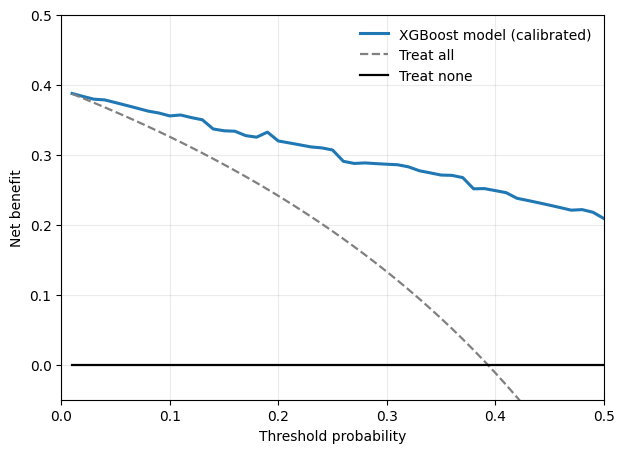

Saved decision_curve.png


In [111]:
from dcurves import dca


dca_df = pd.DataFrame({
    'y_test': y_test.reset_index(drop=True),
    'xgb_model': y_proba
})

dca_result = dca(
    data=dca_df,
    outcome='y_test',
    modelnames=['xgb_model'],
    thresholds=np.arange(0.01, 0.51, 0.01)
)

print(dca_result.columns.tolist())
print(dca_result['model'].unique())

# Readable legend names instead of the raw variable name
labels = {
    'xgb_model': 'XGBoost model (calibrated)',
    'all':       'Treat all',
    'none':      'Treat none',
}
styles = {
    'xgb_model': dict(color='tab:blue', lw=2.2),
    'all':       dict(color='gray',     lw=1.6, ls='--'),
    'none':      dict(color='black',    lw=1.6),
}

fig, ax = plt.subplots(figsize=(7, 5))
for key in ['xgb_model', 'all', 'none']:
    d = dca_result[dca_result['model'] == key].sort_values('threshold')
    ax.plot(d['threshold'], d['net_benefit'], label=labels[key], **styles[key])

ax.set_xlabel('Threshold probability')
ax.set_ylabel('Net benefit')
ax.set_xlim(0, 0.5)
ax.set_ylim(-0.05, 0.5)
ax.legend(loc='upper right', frameon=False)
ax.grid(alpha=0.25)

OUT_NAME = "decision_curve.png"
fig.savefig(OUT_NAME, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved", OUT_NAME)

In [112]:
mean_predicted_prob = np.mean(y_proba)
observed_rate = np.mean(y_test)

citl = mean_predicted_prob - observed_rate

print(f"Mean predicted probability: {mean_predicted_prob:.4f}")
print(f"Observed event rate (test set): {observed_rate:.4f}")
print(f"Calibration-in-the-large (predicted - observed): {citl:+.4f}")
print(f"(Ideal value = 0.0000; positive = overprediction, negative = underprediction)")

Mean predicted probability: 0.4006
Observed event rate (test set): 0.3930
Calibration-in-the-large (predicted - observed): +0.0076
(Ideal value = 0.0000; positive = overprediction, negative = underprediction)


# SENSITIVITY ANALYSIS: One-Hot vs Ordinal Encoding

In [113]:
from scipy.stats import ttest_rel, wilcoxon, spearmanr
from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier
import shap

# ---- 1. Non-ordinal (nominal) predictors flagged for re-encoding
nominal_vars = [
    'Gender',
    'Smoking Status',
    'Urination frequency',
    'Family history of hypertension',
    'Family history of diabetes',
    'History of kidney stones/UTI',
]
nominal_vars = [v for v in nominal_vars if v in predictor_cols]

# ---- 2. Rebuild X_train / X_test with nominal vars as text labels,

def to_labeled(df_part, cols):
    out = df_part.copy()
    for c in cols:
        out[c] = out[c].map(value_labels[c]).fillna(out[c].astype(str))
    return out

X_train_lab = to_labeled(X_train, nominal_vars)
X_test_lab  = to_labeled(X_test,  nominal_vars)

X_train_oh = pd.get_dummies(X_train_lab, columns=nominal_vars, prefix=nominal_vars)
X_test_oh  = pd.get_dummies(X_test_lab,  columns=nominal_vars, prefix=nominal_vars)
# align columns in case a category is missing in one split
X_train_oh, X_test_oh = X_train_oh.align(X_test_oh, join='left', axis=1, fill_value=0)

print(f"Ordinal predictor count: {X_train.shape[1]}")
print(f"One-hot predictor count: {X_train_oh.shape[1]}")

# ---- 3. Same CV pipeline as the main analysis ----
def evaluate_encoding(X, y, label):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    model = XGBClassifier(
        scale_pos_weight=scale_pos_weight,   # already computed earlier in your notebook
        eval_metric='logloss',
        random_state=42,
    )
    scores = cross_validate(model, X, y, cv=cv, scoring=['f1', 'roc_auc'])
    print(f"[{label}] F1      = {scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}")
    print(f"[{label}] ROC-AUC = {scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}")
    return scores

scores_ordinal = evaluate_encoding(X_train, y_train, "Ordinal (original)")
scores_onehot  = evaluate_encoding(X_train_oh, y_train, "One-Hot (sensitivity)")

# ---- 4. Paired comparison across the 10 folds ----
for metric in ['test_f1', 'test_roc_auc']:
    diff = scores_onehot[metric] - scores_ordinal[metric]
    t_stat, p_t = ttest_rel(scores_onehot[metric], scores_ordinal[metric])
    w_stat, p_w = wilcoxon(scores_onehot[metric], scores_ordinal[metric])
    print(f"\n{metric}: mean diff (one-hot - ordinal) = {diff.mean():.4f}")
    print(f"  paired t-test p = {p_t:.4f} | Wilcoxon p = {p_w:.4f}")

# ---- 5. SHAP comparison (fit on training data, both encodings) ----
def top_shap(X, y, label):
    model = XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss',
                           random_state=42).fit(X, y)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    ranked = pd.Series(np.abs(shap_values).mean(axis=0), index=X.columns).sort_values(ascending=False)
    print(f"\nTop 10 SHAP features [{label}]:")
    print(ranked.head(10))
    return ranked

ranked_ordinal = top_shap(X_train, y_train, "Ordinal")
ranked_onehot  = top_shap(X_train_oh, y_train, "One-Hot (raw dummies)")

# Aggregate one-hot dummy importances back to their parent variable
agg = ranked_onehot.copy()
for var in nominal_vars:
    cols = [c for c in ranked_onehot.index if c.startswith(var + "_")]
    if cols:
        agg[var] = ranked_onehot[cols].sum()
        agg = agg.drop(cols)
agg = agg.sort_values(ascending=False)
print("\nTop 10 SHAP features [One-Hot, aggregated to parent variable]:")
print(agg.head(10))

# ---- 6. Rank-stability statistic to quote in the paper ----
common = [v for v in ranked_ordinal.index if v in agg.index]
rho, p_rho = spearmanr(
    ranked_ordinal[common].rank(ascending=False),
    agg[common].rank(ascending=False)
)
print(f"\nSpearman rank correlation (ordinal vs one-hot feature importance): "
      f"rho = {rho:.3f}, p = {p_rho:.4f}")

Ordinal predictor count: 18
One-hot predictor count: 25
[Ordinal (original)] F1      = 0.6678 ± 0.0715
[Ordinal (original)] ROC-AUC = 0.8413 ± 0.0397
[One-Hot (sensitivity)] F1      = 0.6848 ± 0.0672
[One-Hot (sensitivity)] ROC-AUC = 0.8432 ± 0.0340

test_f1: mean diff (one-hot - ordinal) = 0.0170
  paired t-test p = 0.3131 | Wilcoxon p = 0.3223

test_roc_auc: mean diff (one-hot - ordinal) = 0.0020
  paired t-test p = 0.6905 | Wilcoxon p = 0.6074

Top 10 SHAP features [Ordinal]:
Age                                  2.485932
Herbal/traditional supplement use    0.857743
Bmi                                  0.656398
Family history of hypertension       0.369513
Gender                               0.366891
Daily stress level                   0.337134
Sleep duration                       0.280961
Environmental pollution exposure     0.250651
Smoking Status                       0.207540
Fast food/processed food intake      0.193420
dtype: float32

Top 10 SHAP features [One-Hot (raw dummi

#PROXY-LEARNING SENSITIVITY ANALYSIS

In [114]:
from scipy.stats import spearmanr
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

# Define 6 target-defining variables (excluded from model)
target_vars = [
    'Personal hypertension',
    'Personal diabetes',
    'Edema (swelling)',
    'Urination frequency',
    'History of kidney stones/UTI',
    'Painkiller (NSAID) use frequency'
]

# 18 retained predictors (your actual features used in model)
retained_features = predictor_cols  # from your existing notebook

# ---- STEP 1: Calculate Spearman correlations ----
print("=" * 70)
print("STEP 1: Correlations between retained predictors and target variables")
print("=" * 70)

correlations_list = []
for target in target_vars:
    for feature in retained_features:
        if target in df.columns and feature in df.columns:
            valid_idx = df[[feature, target]].notna().all(axis=1)
            if valid_idx.sum() > 0:
                r, p = spearmanr(df.loc[valid_idx, feature], df.loc[valid_idx, target])
                correlations_list.append({
                    'Feature': feature,
                    'Target': target,
                    'Correlation': r,
                    'P-value': p
                })

corr_df = pd.DataFrame(correlations_list)

# Find strongest proxies (top correlation for each target)
strongest_proxies = corr_df.loc[corr_df.groupby('Target')['Correlation'].idxmax()]
print("\nStrongest proxies (by target variable):")
print(strongest_proxies[['Target', 'Feature', 'Correlation']].to_string(index=False))

# Summary statistics
print(f"\nCorrelation range: {corr_df['Correlation'].min():.2f} to {corr_df['Correlation'].max():.2f}")
print(f"Median correlation: {corr_df['Correlation'].abs().median():.2f}")

# ---- STEP 2: Ablation study - remove proxy predictors ----
print("\n" + "=" * 70)
print("STEP 2: Ablation study - removing strongest proxy predictors")
print("=" * 70)

# Identify top 5 strongest proxy predictors overall
top_proxies = corr_df.nlargest(5, 'Correlation')['Feature'].unique()
print(f"\nTop 5 proxy predictors to remove: {list(top_proxies)}")

# Setup cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
model_template = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

ablation_results = []

# Full model baseline
print("\nTraining models...")
scores_full = cross_validate(
    model_template, X_train[retained_features], y_train,
    cv=cv, scoring=['f1', 'roc_auc']
)
f1_baseline = scores_full['test_f1'].mean()
roc_baseline = scores_full['test_roc_auc'].mean()

ablation_results.append({
    'Configuration': 'Full model (baseline)',
    'Features Retained': len(retained_features),
    'F1-score': f1_baseline,
    'F1 Decline (%)': 0.0,
    'ROC-AUC': roc_baseline,
    'ROC Decline (%)': 0.0
})

# Iteratively remove top proxies
for i in range(1, len(top_proxies) + 1):
    features_to_remove = top_proxies[:i]
    features_to_keep = [f for f in retained_features if f not in features_to_remove]

    scores = cross_validate(
        model_template, X_train[features_to_keep], y_train,
        cv=cv, scoring=['f1', 'roc_auc']
    )

    f1_score = scores['test_f1'].mean()
    roc_score = scores['test_roc_auc'].mean()
    f1_decline = ((f1_baseline - f1_score) / f1_baseline) * 100
    roc_decline = ((roc_baseline - roc_score) / roc_baseline) * 100

    ablation_results.append({
        'Configuration': f'Remove top {i} proxy/proxies',
        'Features Retained': len(features_to_keep),
        'F1-score': f1_score,
        'F1 Decline (%)': f1_decline,
        'ROC-AUC': roc_score,
        'ROC Decline (%)': roc_decline
    })

    print(f"  Remove {i} proxy: F1 = {f1_score:.3f} ({f1_decline:+.1f}%), "
          f"ROC-AUC = {roc_score:.3f} ({roc_decline:+.1f}%)")

ablation_df = pd.DataFrame(ablation_results)
print("\n" + ablation_df.to_string(index=False))

# Save results
ablation_df.to_csv('proxy_learning_ablation_results.csv', index=False)
print("\nSaved: proxy_learning_ablation_results.csv")

# ---- STEP 3: Key findings ----
print("\n" + "=" * 70)
print("KEY FINDINGS FOR PAPER")
print("=" * 70)
print(f"\n1. Strongest proxy-predictor associations:")
for _, row in strongest_proxies.iterrows():
    print(f"   {row['Feature']} ↔ {row['Target']}: ρ = {row['Correlation']:.2f}")

print(f"\n2. Ablation analysis results:")
print(f"   - Full model F1:             {f1_baseline:.3f}")
print(f"   - Remove top 5 proxies F1:   {ablation_results[-1]['F1-score']:.3f}")
print(f"   - Performance retained:      {100 - ablation_results[-1]['F1 Decline (%)']:.1f}%")

print(f"\n3. Interpretation:")
print(f"   Even without the 5 strongest proxy predictors, the model retains")
print(f"   {100 - ablation_results[-1]['F1 Decline (%)']:.1f}% of baseline performance.")
print(f"   This indicates meaningful independent signal beyond proxy reconstruction.")

STEP 1: Correlations between retained predictors and target variables

Strongest proxies (by target variable):
                          Target Feature  Correlation
                Edema (swelling)     Age     0.474483
    History of kidney stones/UTI     Age     0.468203
Painkiller (NSAID) use frequency     Age     0.419559
               Personal diabetes     Age     0.486651
           Personal hypertension     Age     0.309926
             Urination frequency     Age     0.463533

Correlation range: -0.08 to 0.49
Median correlation: 0.09

STEP 2: Ablation study - removing strongest proxy predictors

Top 5 proxy predictors to remove: ['Age']

Training models...
  Remove 1 proxy: F1 = 0.602 (+14.5%), ROC-AUC = 0.714 (+17.1%)

             Configuration  Features Retained  F1-score  F1 Decline (%)  ROC-AUC  ROC Decline (%)
     Full model (baseline)                 18  0.704315        0.000000 0.861175          0.00000
Remove top 1 proxy/proxies                 17  0.602425       14.4

# SUBGROUP AND FAIRNESS ANALYSIS (with 95% CI)

In [116]:
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')

# ---- Single source of truth for the threshold (Youden's J) ----
THRESHOLD = 0.4109

# ---- Bootstrap helper: gives 95% CI for each metric ----

def bootstrap_metrics(y_true, y_pred_proba, threshold=THRESHOLD, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred_proba = np.asarray(y_pred_proba)
    n = len(y_true)

    aucs, sens_list, spec_list, ece_list = [], [], [], []

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        yt, yp = y_true[idx], y_pred_proba[idx]
        if len(np.unique(yt)) < 2:
            continue
        try:
            aucs.append(roc_auc_score(yt, yp))
        except Exception:
            pass
        tn, fp, fn, tp = confusion_matrix(yt, yp > threshold, labels=[0, 1]).ravel()
        if (tp + fn) > 0:
            sens_list.append(tp / (tp + fn))
        if (tn + fp) > 0:
            spec_list.append(tn / (tn + fp))
        try:
            frac_pos, mean_pred = calibration_curve(yt, yp, n_bins=5)
            ece_list.append(np.abs(frac_pos - mean_pred).mean())
        except Exception:
            pass

    def ci_str(arr):
        arr = np.array(arr)
        if len(arr) < 10:
            return "NA"
        lo, hi = np.percentile(arr, [2.5, 97.5])
        return f"({lo:.3f}\u2013{hi:.3f})"

    return ci_str(aucs), ci_str(sens_list), ci_str(spec_list), ci_str(ece_list)


def evaluate_subgroup(y_true_subgroup, y_pred_subgroup, n, threshold=THRESHOLD):
    roc_auc = roc_auc_score(y_true_subgroup, y_pred_subgroup)
    tn, fp, fn, tp = confusion_matrix(y_true_subgroup, y_pred_subgroup > threshold, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    frac_pos, mean_pred = calibration_curve(y_true_subgroup, y_pred_subgroup, n_bins=5)
    calibration_error = np.abs(frac_pos - mean_pred).mean()

    auc_ci, sens_ci, spec_ci, ece_ci = bootstrap_metrics(
        y_true_subgroup, y_pred_subgroup, threshold=threshold
    )

    return {
        'N': n,
        'ROC-AUC (95% CI)': f"{roc_auc:.3f} {auc_ci}",
        'Sensitivity (95% CI)': f"{sensitivity:.3f} {sens_ci}",
        'Specificity (95% CI)': f"{specificity:.3f} {spec_ci}",
        'Calibration Error (95% CI)': f"{calibration_error:.3f} {ece_ci}"
    }


# ---- Define subgroups ----

gender_groups = {0: 'Female', 1: 'Male'}
age_groups_dict = {
    '<40': df[df['Age'] < 40],
    '40-50': df[(df['Age'] >= 40) & (df['Age'] < 50)],
    '>50': df[df['Age'] >= 50]
}
ses_groups = {0: 'Low', 1: 'Middle', 2: 'High'}

# ---- Predictions and true labels ----

y_test_pred = calibrated_model.predict_proba(X_test)[:, 1]
y_test_true = y_test

excluded_subgroups = []  # track any subgroup dropped for n < 20

print(f"Using threshold = {THRESHOLD}  (pipeline optimal_threshold = {optimal_threshold:.4f})")

# ---- GENDER SUBGROUP ANALYSIS ----

print("=" * 70)
print("GENDER SUBGROUP ANALYSIS")
print("=" * 70)

gender_results = []
for gender_code, gender_name in gender_groups.items():
    mask = X_test.index.isin(df[df['Gender'] == gender_code].index)
    n = mask.sum()
    if n < 20:
        excluded_subgroups.append(f"Gender = {gender_name} (n = {n})")
        continue
    row = evaluate_subgroup(y_test_true[mask], y_test_pred[mask], n)
    row = {'Subgroup': gender_name, **row}
    gender_results.append(row)

gender_df = pd.DataFrame(gender_results)
print(gender_df.to_string(index=False))

# ---- AGE GROUP ANALYSIS ----

print("\n" + "=" * 70)
print("AGE GROUP ANALYSIS")
print("=" * 70)

age_results = []
for age_label, age_df_subset in age_groups_dict.items():
    mask = X_test.index.isin(age_df_subset.index)
    n = mask.sum()
    if n < 20:
        excluded_subgroups.append(f"Age group = {age_label} years (n = {n})")
        continue
    row = evaluate_subgroup(y_test_true[mask], y_test_pred[mask], n)
    row = {'Age Group': age_label, **row}
    age_results.append(row)

age_df = pd.DataFrame(age_results)
print(age_df.to_string(index=False))

# ---- SOCIOECONOMIC STATUS ANALYSIS ----

print("\n" + "=" * 70)
print("SOCIOECONOMIC STATUS ANALYSIS")
print("=" * 70)

ses_results = []
for ses_code, ses_name in ses_groups.items():
    mask = X_test.index.isin(df[df['Socioeconomic Status'] == ses_code].index)
    n = mask.sum()
    if n < 20:
        excluded_subgroups.append(f"SES = {ses_name} (n = {n})")
        continue
    row = evaluate_subgroup(y_test_true[mask], y_test_pred[mask], n)
    row = {'SES': ses_name, **row}
    ses_results.append(row)

ses_df = pd.DataFrame(ses_results)
print(ses_df.to_string(index=False))

# ---- REPORT ANY EXCLUDED SUBGROUPS EXPLICITLY ----

print("\n" + "=" * 70)
print("EXCLUDED SUBGROUPS (n < 20, pre-specified minimum threshold)")
print("=" * 70)
if excluded_subgroups:
    for item in excluded_subgroups:
        print(" -", item)
else:
    print("None excluded.")

# ---- SAVE: one combined CSV for submission ----

combined = pd.concat(
    [
        gender_df.rename(columns={'Subgroup': 'Group'}).assign(Analysis='Gender'),
        age_df.rename(columns={'Age Group': 'Group'}).assign(Analysis='Age'),
        ses_df.rename(columns={'SES': 'Group'}).assign(Analysis='SES'),
    ],
    ignore_index=True
)
combined['Threshold'] = THRESHOLD
combined = combined[['Analysis', 'Group', 'Threshold'] + [c for c in combined.columns
                                                          if c not in ('Analysis', 'Group', 'Threshold')]]
combined.to_csv('R2_subgroups_youden.csv', index=False)

print(f"\nSaved R2_subgroups_youden.csv at threshold {THRESHOLD}")


Using threshold = 0.4109  (pipeline optimal_threshold = 0.4109)
GENDER SUBGROUP ANALYSIS
Subgroup   N    ROC-AUC (95% CI) Sensitivity (95% CI) Specificity (95% CI) Calibration Error (95% CI)
  Female  71 0.936 (0.873–0.982)  0.762 (0.571–0.941)  0.880 (0.782–0.960)        0.220 (0.105–0.319)
    Male 130 0.890 (0.832–0.939)  0.828 (0.723–0.922)  0.792 (0.690–0.881)        0.051 (0.034–0.154)

AGE GROUP ANALYSIS
Age Group   N    ROC-AUC (95% CI) Sensitivity (95% CI) Specificity (95% CI) Calibration Error (95% CI)
      <40 160 0.871 (0.816–0.921)  0.643 (0.490–0.789)  0.856 (0.791–0.917)        0.045 (0.033–0.158)
    40-50  25 0.591 (0.159–0.917)  1.000 (1.000–1.000)  0.000 (0.000–0.000)        0.052 (0.019–0.211)

SOCIOECONOMIC STATUS ANALYSIS
   SES  N    ROC-AUC (95% CI) Sensitivity (95% CI) Specificity (95% CI) Calibration Error (95% CI)
   Low 81 0.882 (0.802–0.946)  0.696 (0.500–0.875)  0.793 (0.685–0.892)        0.189 (0.095–0.294)
Middle 99 0.917 (0.858–0.966)  0.833 (0.714–0.9

In [117]:
# Strategy A (Class Weighting) grids, exactly as used in the tuning cell
grids_a = {
    'Logistic Regression': param_grid_lr,
    'Random Forest':       param_grid_rf,
    'XGBoost':             param_grid_xgb,
    'SVM':                 param_grid_svm,
    'LightGBM':            param_grid_lgbm,
}

# Strategy B (SMOTE) grids, exactly as used in the tuning cell
grids_b = {
    'Logistic Regression': param_grid_smote_lr,
    'Random Forest':       param_grid_smote_rf,
    'XGBoost':             param_grid_smote_xgb,
    'SVM':                 param_grid_smote_svm_light,
    'LightGBM':            param_grid_smote_lgbm,
}

# Search settings used in the notebook
search_settings = {
    ('Class Weighting', 'Logistic Regression'): 'RandomizedSearchCV, n_iter=40, 10-fold stratified CV, refit on F1',
    ('Class Weighting', 'Random Forest'):       'RandomizedSearchCV, n_iter=40, 10-fold stratified CV, refit on F1',
    ('Class Weighting', 'XGBoost'):             'RandomizedSearchCV, n_iter=40, 10-fold stratified CV, refit on F1',
    ('Class Weighting', 'SVM'):                 'RandomizedSearchCV, n_iter=40, 10-fold stratified CV, refit on F1',
    ('Class Weighting', 'LightGBM'):            'RandomizedSearchCV, n_iter=40, 10-fold stratified CV, refit on F1',
    ('SMOTE', 'Logistic Regression'):           'RandomizedSearchCV, n_iter=40, 10-fold stratified CV, refit on F1',
    ('SMOTE', 'Random Forest'):                 'RandomizedSearchCV, n_iter=40, 10-fold stratified CV, refit on F1',
    ('SMOTE', 'XGBoost'):                       'RandomizedSearchCV, n_iter=40, 10-fold stratified CV, refit on F1',
    ('SMOTE', 'LightGBM'):                      'RandomizedSearchCV, n_iter=40, 10-fold stratified CV, refit on F1',
    ('SMOTE', 'SVM'):                           'RandomizedSearchCV, n_iter=6, 5-fold stratified CV, refit on F1 (lightweight grid)',
}


def clean(v):
    """Make numpy types and long floats readable."""
    if isinstance(v, (np.floating, float)):
        return f"{float(v):.4g}"
    if isinstance(v, (np.integer,)):
        return str(int(v))
    return str(v)


def strip_prefix(name):
    return name.replace('model__', '')


rows = []
for strategy, grids, results in [
    ('Class Weighting', grids_a, strategy_a_results),
    ('SMOTE',           grids_b, strategy_b_results),
]:
    for model_name, grid in grids.items():
        best = results[model_name]['Best_Params']
        for param, space in grid.items():
            rows.append({
                'Strategy': strategy,
                'Model': model_name,
                'Hyperparameter': strip_prefix(param),
                'Search space': ', '.join(clean(x) for x in space),
                'Selected value': clean(best[param]) if param in best else 'NA',
                'Search settings': search_settings[(strategy, model_name)],
                'CV F1 (mean)': f"{results[model_name]['Mean_F1']:.4f}",
                'CV ROC-AUC (mean)': f"{results[model_name]['Mean_ROC_AUC']:.4f}",
                'Final model': 'Yes' if (model_name == best_model_name and strategy == best_strategy) else '',
            })

s4_df = pd.DataFrame(rows)

# Safety check: every selected param must come from the grid
for strategy, grids, results in [('Class Weighting', grids_a, strategy_a_results),
                                 ('SMOTE', grids_b, strategy_b_results)]:
    for model_name, grid in grids.items():
        missing = set(results[model_name]['Best_Params']) - set(grid)
        if missing:
            print(f"WARNING: {strategy} / {model_name}: selected params not in grid: {missing}")

print(s4_df.to_string(index=False))

s4_df.to_csv('R6_hyperparameters_S4.csv', index=False)
print(f"\nSaved R6_hyperparameters_S4.csv  ({len(s4_df)} rows)")
print(f"Final model flagged: {best_model_name} / {best_strategy}")


       Strategy               Model    Hyperparameter                 Search space     Selected value                                                                    Search settings CV F1 (mean) CV ROC-AUC (mean) Final model
Class Weighting Logistic Regression      class_weight                     balanced           balanced                  RandomizedSearchCV, n_iter=40, 10-fold stratified CV, refit on F1       0.7384            0.8746            
Class Weighting Logistic Regression                 C 0.001, 0.01, 0.1, 1, 10, 100                0.1                  RandomizedSearchCV, n_iter=40, 10-fold stratified CV, refit on F1       0.7384            0.8746            
Class Weighting Logistic Regression            solver              liblinear, saga          liblinear                  RandomizedSearchCV, n_iter=40, 10-fold stratified CV, refit on F1       0.7384            0.8746            
Class Weighting Logistic Regression           penalty                       l1, l2      